# Hotel Room-Nights Forecasting — REAL DATA

**Enjoy Costa Rica — Revenue Analytics**

Pronóstico de **room nights** sobre las fuentes reales de producción:
`staging.enjoy_fac_hotel` (snapshots de reservas: `snap_flag` 0=real, 1=futuro) y
`public.enjoy_inventory` (capacidad oficial). Las ~14M de filas **nunca salen de la
base**: sistemas ejecuta las 3 queries de agregación (documentadas en
`src/forecasting/data/real_sources.py`) y exporta CSVs compactos que este notebook consume.

| Sección | Contenido |
|---|---|
| 1 | Carga de agregados reales + reporte de calidad (mapeo de propiedades, fallback de capacidad, cold-start, exclusión de propiedades congeladas) |
| 2 | EDA: demanda del portafolio, ocupación, **curvas de pickup** |
| 3 | Preprocesamiento honesto + features de libros (rotb_d90/180/365, regla as-of) |
| 4-6 | Prophet/SARIMAX/ETS + GBMs (tuning honesto con covariantes) + PatchTST |
| 7 | Comparación + sesgo + **backtesting rolling-origin** + DM Newey-West |
| 8 | Pronóstico 90 días **bottom-up operacional** (modelo por propiedad vía folds, guardas short/stale/cold) + bandas conformales 12 ventanas + cross-check top-down + cobertura de libros |

> **Protocolo honesto**: multi-paso real (recursivo), baseline SeasonalNaive, reales
> del test jamás como entradas, techo de capacidad, bandas con cobertura reportada.
>
> Los datos de este run provienen de las **exportaciones reales de sistemas**
> (`data/roomnights_real/`: demanda, libros de reservas, capacidad). Con cada
> export nueva: reentrenar y re-validar.

In [1]:
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

with open(PROJECT_ROOT / 'config.yaml') as f:
    CONFIG = yaml.safe_load(f)

RN = CONFIG['roomnights_real']
TARGET_COL = 'rooms_sold'
AVAIL_COL = 'available_rooms'
LEAD_BUCKETS = RN['lead_buckets']
MULTI_STEP_MIN_LEAD = RN['multi_step_min_lead']
HORIZON = RN['horizon_days']
TRAIN_YEARS = RN['training_window_years']

print(f"Target: {TARGET_COL} | leads: {LEAD_BUCKETS} | multi-step >= {MULTI_STEP_MIN_LEAD}d")
print(f"Horizonte: {HORIZON}d | ventana de entrenamiento: {TRAIN_YEARS} años")

Target: rooms_sold | leads: [7, 14, 30, 60, 90, 180, 365] | multi-step >= 365d
Horizonte: 365d | ventana de entrenamiento: 4 años


In [2]:
from src.forecasting.data.real_sources import load_real_aggregates
from src.forecasting.data.pickup import (
    build_pickup_features, portfolio_pickup, multi_step_pickup_columns,
)
from src.forecasting.data.synthetic_real import generate_real_schema_sample
from src.forecasting.data.aggregation import aggregate_daily_target, apply_capacity_ceiling, implied_occupancy
from src.forecasting.preprocessing import PreprocessingPipeline
from src.forecasting.preprocessing.features import TemporalFeatureEngineer
from src.forecasting.preprocessing.holidays import HolidayFeatureEngineer
from src.forecasting.models.statistical import ProphetForecaster, SARIMAXForecaster, ETSForecaster
from src.forecasting.models.ml import LightGBMForecaster, XGBoostForecaster, CatBoostForecaster
from src.forecasting.models.tuning import tune_gbm, tune_prophet_grid
from src.forecasting.models.dl import TimesFMForecaster, PatchTSTForecaster
from src.forecasting.evaluation import Evaluator, EvaluationVisualizer
from src.forecasting.evaluation.backtesting import make_rolling_folds, rolling_origin_backtest
from src.forecasting.evaluation.conformal import (
    per_horizon_conformal_bands, empirical_coverage, summarize_bands,
)
from src.forecasting.forecasting.recursive import recursive_forecast

print("All modules imported successfully!")

All modules imported successfully!


---
## Section 1: Real Aggregates — carga y calidad

Tres agregados (exportados por sistemas con las queries de `real_sources.py`):
- **demand**: `property, stay_date, rooms_sold, room_revenue` — realizado (`snap_flag=0`), sin SYSTEM_ADJUST
- **pickup**: `property, stay_date, lead_days, rooms_booked` — libros por anticipación (`snap_flag=1`)
- **capacity**: `property, business_date, available_rooms` — inventario oficial

El loader canoniza propiedades (códigos y nombres → una clave), valida unicidad
flag-0, parsea decimales con coma y aplica el fallback de capacidad.

El reporte de calidad incluye la frescura de cada propiedad; las **congeladas**
(`frozen_properties` en `config.yaml`, confirmadas por operaciones) se muestran
pero se **excluyen** de todo el modelado y del pronóstico.

In [3]:
# Load the real aggregates (synthetic real-schema sample for offline runs;
# swap the paths for the systems exports and everything runs unchanged).
base = PROJECT_ROOT / RN['csv_paths']['demand'].split('data/')[0] / 'data' if False else PROJECT_ROOT / 'data'
paths = {
    'demand': PROJECT_ROOT / RN['csv_paths']['demand'],
    'pickup': PROJECT_ROOT / RN['csv_paths']['pickup'],
    'capacity': PROJECT_ROOT / RN['csv_paths']['capacity'],
}
missing = [p for p in paths.values() if not Path(p).exists()]
if missing:
    print("Aggregates not found -> generating the synthetic real-schema sample...")
    generate_real_schema_sample(
        PROJECT_ROOT / 'data' / 'roomnights_real_sample',
        n_days=365 * 4, seed=SEED, lead_buckets=LEAD_BUCKETS, future_horizon_days=400,
    )

quality_log = {}
AGG = load_real_aggregates(
    paths['demand'], paths['pickup'], paths['capacity'],
    mapping_config=RN, exclusions_log=quality_log,
)
demand, pickup, capacity = AGG['demand'], AGG['pickup'], AGG['capacity']

display_name = RN['display_names']
print(f"Demand: {len(demand)} filas | {demand['property'].nunique()} propiedades | "
      f"{demand['stay_date'].min().date()} -> {demand['stay_date'].max().date()}")
print(f"Pickup: {len(pickup)} filas | stays hasta {pickup['stay_date'].max().date()} "
      f"| leads {sorted(pickup['lead_days'].unique())[:8]}")
print(f"Capacity: {len(capacity)} filas | fallback days: {quality_log.get('capacity_fallback_days', 0)}")
print(f"Revenue invalid values: {quality_log.get('invalid_revenue_values', 0)}")

src.forecasting.data.real_sources - INFO - Real aggregates loaded: demand=13874 rows (8 properties), pickup=1565467 rows, capacity=39520 rows (6 fallback-filled days)


Demand: 13874 filas | 8 propiedades | 2013-09-23 -> 2026-10-06
Pickup: 1565467 filas | stays hasta 2028-12-18 | leads [0, 1, 2, 3, 4, 5, 6, 7]
Capacity: 39520 filas | fallback days: 6
Revenue invalid values: 0


In [4]:
# Per-property report: history depth, demand level, occupancy, cold-start flag
cold_min = RN['cold_start_min_history_days']
frozen_props = list(RN.get('frozen_properties') or [])
unknown_frozen = [p for p in frozen_props if p not in demand['property'].unique()]
if unknown_frozen:
    raise ValueError(f"frozen_properties desconocidas en los datos: {unknown_frozen}")

prop_rows = []
for prop, g in demand.groupby('property'):
    days = g['stay_date'].nunique()
    cap_g = capacity[capacity['property'] == prop].set_index('business_date')['available_rooms']
    occ = (g.set_index('stay_date')['rooms_sold'] / cap_g.reindex(g['stay_date'])).mean()
    prop_rows.append({
        'property': display_name.get(prop, prop),
        'key': prop,
        'realized_days': days,
        'last_realized': g['stay_date'].max(),
        'fresh': g['stay_date'].max() >= demand['stay_date'].max() - pd.Timedelta(days=7),
        'mean_rooms': g['rooms_sold'].mean(),
        'mean_occupancy': occ,
        'cold_start': days < cold_min,
        'frozen': prop in frozen_props,
    })
prop_report = pd.DataFrame(prop_rows).set_index('property')
display(prop_report.round(3))
n_cold = int(prop_report['cold_start'].sum())
print(f"Cold-start properties (<{cold_min} días de historia): {n_cold}")

# Frozen properties (closed/paused, confirmed by operations): reported above but
# excluded from ALL modeling/forecast frames — their stale history would
# contaminate portfolio patterns and their future is not operable.
if frozen_props:
    frozen_display = [display_name.get(k, k) for k in frozen_props]
    demand = demand[~demand['property'].isin(frozen_props)].reset_index(drop=True)
    pickup = pickup[~pickup['property'].isin(frozen_props)].reset_index(drop=True)
    capacity = capacity[~capacity['property'].isin(frozen_props)].reset_index(drop=True)
    print(f"Propiedades CONGELADAS excluidas del modelo y del pronóstico: {frozen_display}")
    print(f"Portafolio activo: {demand['property'].nunique()} propiedades | "
          f"{len(demand)} filas de demanda | "
          f"{demand['stay_date'].min().date()} -> {demand['stay_date'].max().date()}")


,key,realized_days,last_realized,fresh,mean_rooms,mean_occupancy,cold_start,frozen
property,,,,,,,,
Hotel Royal Corin,corin,1375,2026-10-06,True,39.582,0.529,False,False
Fiesta,fiesta,1010,2026-10-06,True,336.878,0.826,False,False
Lapas,lapas,936,2026-07-04,False,42.608,0.571,False,True
LIRAK,lirak,4087,2025-06-30,False,25.549,0.481,False,True
LIREL,lirel,3808,2026-10-06,True,64.635,0.628,False,False
Marina,marina,1375,2026-10-06,True,28.425,0.444,False,False
SJO (SJOSL),sjo,273,2026-10-06,True,28.216,0.393,False,False
Villas,villas,1010,2026-10-06,True,98.176,0.451,False,False


Cold-start properties (<90 días de historia): 0
Propiedades CONGELADAS excluidas del modelo y del pronóstico: ['Lapas', 'LIRAK']
Portafolio activo: 6 propiedades | 8851 filas de demanda | 2016-02-01 -> 2026-10-06


---
## Section 2: EDA sobre los agregados reales

**Preguntas de modelado**: ¿cómo es la demanda del portafolio vs su techo? y la
joya — **¿cuánta información llevan las curvas de pickup?**

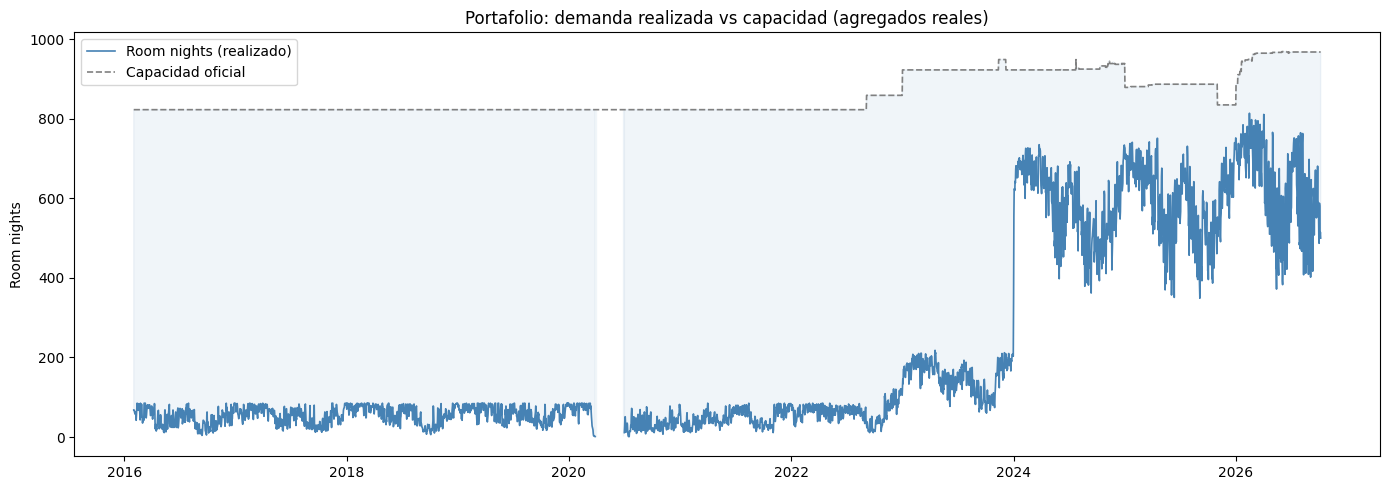

Dias: 3901 | ocupacion media: 22.9%


In [5]:
# Portfolio daily series: demand vs capacity
port_demand = demand.groupby('stay_date')['rooms_sold'].sum().sort_index()
# Contiguous daily calendar: unreported days become NaN rows so the pipeline's
# imputation (ffill) and row-shift features keep DAY semantics (92 historical
# gaps exist, all pre-2022; recent window is contiguous).
_full_idx = pd.date_range(port_demand.index.min(), port_demand.index.max(), freq='D')
port_demand = port_demand.reindex(_full_idx)
port_capacity = capacity.groupby('business_date')['available_rooms'].sum().sort_index()
port_capacity = port_capacity.reindex(_full_idx).ffill()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(port_demand.index, port_demand.values, label='Room nights (realizado)', color='steelblue', lw=1.2)
ax.plot(port_capacity.index, port_capacity.values, label='Capacidad oficial', color='gray', ls='--', lw=1.2)
ax.fill_between(port_demand.index, port_demand.values, port_capacity.values, alpha=0.08, color='steelblue')
ax.set_title('Portafolio: demanda realizada vs capacidad (agregados reales)')
ax.set_ylabel('Room nights'); ax.legend()
fig.tight_layout(); plt.show()

print(f"Dias: {len(port_demand)} | ocupacion media: {(port_demand / port_capacity).mean():.1%}")

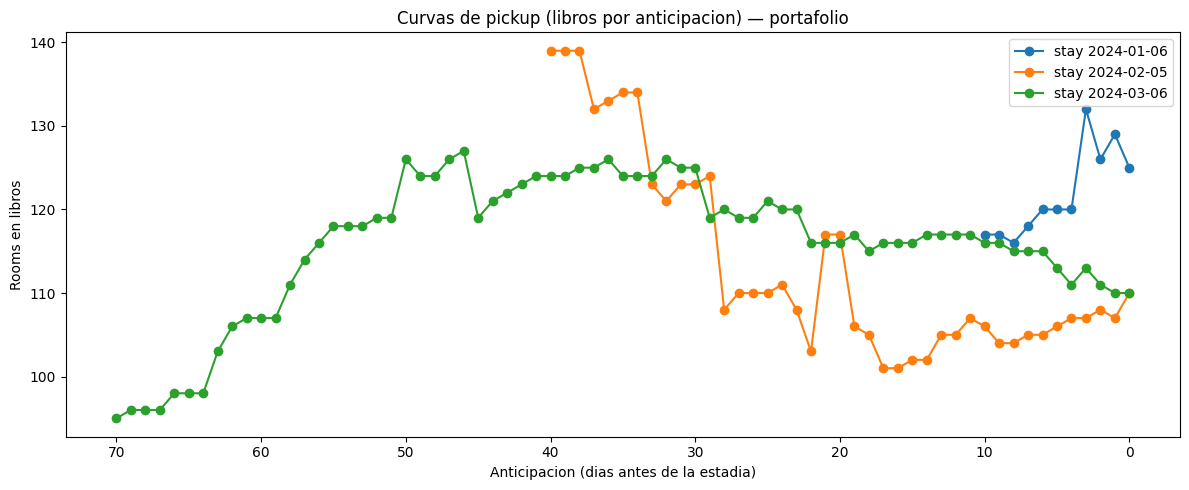

src.forecasting.data.pickup - INFO - Pickup features: 1751 (property, stay_date) rows x 7 buckets | coverage d7=99.6%, d365=79.1%


Correlacion rotb_d90 vs realizado: 0.479 en 925 fechas


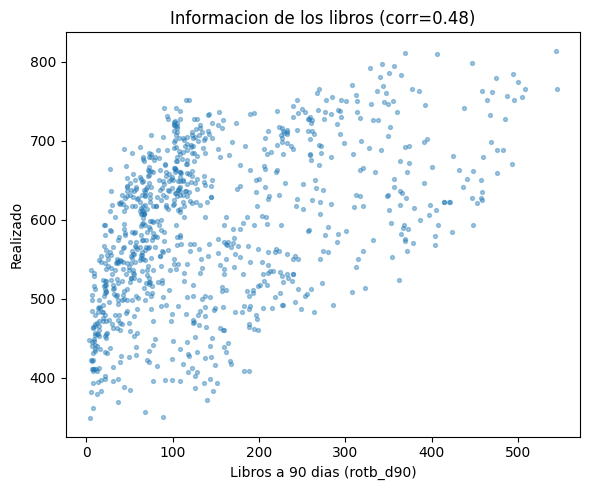

In [6]:
# The jewel: pickup curves — books by lead time for sample future stays
future_stays = sorted(pickup['stay_date'].unique())
sample_stays = [pd.Timestamp(future_stays[i]) for i in (10, 40, 70)]
fig, ax = plt.subplots(figsize=(12, 5))
for stay in sample_stays:
    g = pickup[pickup['stay_date'] == stay].groupby('lead_days')['rooms_booked'].sum().sort_index()
    ax.plot(g.index, g.values, marker='o', label=f'stay {stay.date()}')
ax.invert_xaxis()  # right = closer to the stay
ax.set_title('Curvas de pickup (libros por anticipacion) — portafolio')
ax.set_xlabel('Anticipacion (dias antes de la estadia)'); ax.set_ylabel('Rooms en libros'); ax.legend()
fig.tight_layout(); plt.show()

# Information content: rotb_d90 vs realized (portfolio)
port_pickup = portfolio_pickup(pickup, LEAD_BUCKETS)
info = port_pickup.merge(port_demand.rename('realized'), left_on='stay_date', right_index=True)
info_recent = info.dropna(subset=['rotb_d90', 'realized'])
corr = info_recent['rotb_d90'].corr(info_recent['realized'])
print(f"Correlacion rotb_d90 vs realizado: {corr:.3f} en {len(info_recent)} fechas")
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(info_recent['rotb_d90'], info_recent['realized'], s=8, alpha=0.4)
ax.set_xlabel('Libros a 90 dias (rotb_d90)'); ax.set_ylabel('Realizado')
ax.set_title(f'Informacion de los libros (corr={corr:.2f})')
fig.tight_layout(); plt.show()

---
## Section 3: Preprocesamiento honesto + features de libros (as-of)

**Reglas**: (1) solo `snap_flag=0` alimenta el target; (2) features = familia del
target + calendario + festivos CR + capacidad oficial + **libros a ≥90 días**
(rotb_d90/180/365) — as-of seguros para una ventana multi-paso de 90d: su snapshot
(stay − lead ≤ origen) siempre ocurre antes del origen; (3) monetario excluido
(futuro desconocido); (4) evaluación recursiva multi-paso; (5) baseline naive.

In [7]:
# ---- Portfolio modeling frame ----
# Training window policy: recent TRAIN_YEARS years (old regimes excluded, documented)
cutoff = port_demand.index.max() - pd.DateOffset(years=TRAIN_YEARS)
demand_recent = port_demand[port_demand.index > cutoff]
print(f"Ventana de entrenamiento: {demand_recent.index.min().date()} -> {demand_recent.index.max().date()} "
      f"({len(demand_recent)} dias)")

df_agg = pd.DataFrame({
    'date': demand_recent.index,
    TARGET_COL: demand_recent.values,
    AVAIL_COL: port_capacity.reindex(demand_recent.index).values,
}).reset_index(drop=True)

# Pickup features for ALL stay dates (history + test + future): as-of safe at
# lead >= 90 — the snapshot for a date t happens at t-90, before any origin that
# forecasts t. Books for FUTURE stays come from the current reservations book.
port_pickup_feats = port_pickup.set_index('stay_date')
rotb_cols_ml = multi_step_pickup_columns(LEAD_BUCKETS, MULTI_STEP_MIN_LEAD)
print(f"Features de libros multi-paso (as-of seguras): {rotb_cols_ml}")

for col in rotb_cols_ml:
    df_agg[col] = port_pickup_feats[col].reindex(df_agg['date']).values
print(f"Rotb coverage en la ventana: {df_agg[rotb_cols_ml[0]].notna().mean():.1%}")

pipeline = PreprocessingPipeline(
    missing_strategy=CONFIG['preprocessing']['missing_values']['strategy'],
    outlier_method=CONFIG['preprocessing']['outliers']['method'],
    outlier_action=CONFIG['preprocessing']['outliers']['action'],
    feature_config={'lags': [1, 7, 14, 30, 365],
                    'rolling_windows': [7, 14, 30, 90],
                    'rolling_stats': ['mean', 'std', 'min', 'max'],
                    'expanding_stats': ['mean', 'std'],
                    'cyclical_features': ['dayofweek', 'dayofyear', 'month'],
                    'target_cols': [TARGET_COL]},
    split_config=CONFIG['preprocessing']['split'],
    scale_method=None,
    target_cols=[TARGET_COL],
)
split_result, train_feat, val_feat, test_feat = pipeline.run(df_agg, date_col='date')

keep = ['date', TARGET_COL, AVAIL_COL] + rotb_cols_ml
train_df, val_df, test_df = train_feat[keep].copy(), val_feat[keep].copy(), test_feat[keep].copy()
test_start = test_df['date'].min()
actuals_test = test_df[TARGET_COL].values
test_dates = pd.to_datetime(test_df['date'])

history_eval = df_agg.loc[df_agg['date'] < test_start, keep].reset_index(drop=True)
full_history = df_agg[keep].copy()

# Forward-known covariates for any window: books columns by date
def books_covariates(dates):
    idx = pd.DatetimeIndex(dates)
    cov = pd.DataFrame({'date': idx})
    for col in rotb_cols_ml:
        cov[col] = port_pickup_feats[col].reindex(idx).values
    return cov

print(f"Train: {len(train_feat)}d | Val: {len(val_feat)}d | Test: {len(test_feat)}d | gap={split_result.gap_days}d")
print(f"Historia disponible al test: {len(history_eval)} dias (hasta {history_eval['date'].max().date()})")
print(f"Covariantes de libros para el test: {books_covariates(test_dates).notna().all().iloc[1:].all()}")

src.forecasting.preprocessing.missing - INFO - Imputed 812 missing values in 'rotb_d365' (ffill_bfill)


src.forecasting.preprocessing.splitter - INFO - Temporal split: train=1022, val=212, test=213 (gap=7 days)


src.forecasting.preprocessing.splitter - INFO - Split dates: train_end=2025-07-24, val_end=2026-02-28


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 45 columns


Ventana de entrenamiento: 2022-10-07 -> 2026-10-06 (1461 dias)
Features de libros multi-paso (as-of seguras): ['rotb_d365']
Rotb coverage en la ventana: 44.4%


...

src.forecasting.preprocessing.outliers - INFO - Outliers in 'rotb_d365': 208 (20.35%) — action: flag


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rotb_d365': 212 (100.00%) — action: flag


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rotb_d365': 213 (100.00%) — action: flag


src.forecasting.preprocessing.pipeline - INFO - Pipeline complete: train=1022 rows/52 cols, val=212, test=213


Train: 1022d | Val: 212d | Test: 213d | gap=7d
Historia disponible al test: 1248 dias (hasta 2026-03-07)
Covariantes de libros para el test: True


In [8]:
# ML feature set (forward-known only)
drop_cols = ['date', 'hotel_id', TARGET_COL]
excluded_prefixes = ('revenue', 'room_revenue', 'adr', 'revpar', 'occupancy_rate')
feature_cols_ml = [
    c for c in train_feat.columns
    if c not in drop_cols and not c.startswith(excluded_prefixes)
]
for must in [AVAIL_COL] + rotb_cols_ml:
    assert must in feature_cols_ml, f"{must} debe ser feature forward-known"
print(f"ML features ({len(feature_cols_ml)}): includes capacity + books {rotb_cols_ml}")

ML features (50): includes capacity + books ['rotb_d365']


---
## Section 4: Statistical Models + tuning honesto

El tuning optimiza el **MAE recursivo multi-paso en la ventana de validación** —
la métrica que el negocio sentirá, nunca atajos one-step.

In [9]:
from src.forecasting.models.tuning import tune_prophet_grid

val_start = val_df['date'].min()
pre_val_history = df_agg.loc[df_agg['date'] < val_start, keep].reset_index(drop=True)
val_dates_t = pd.to_datetime(val_df['date'])
val_actuals_t = val_df[TARGET_COL].values
val_cov = books_covariates(val_dates_t)

def prepare_features(hist):
    out = pipeline.feature_engineer.transform(hist)
    out = pipeline.holiday_engineer.transform(out)
    out = pipeline.outlier_handler.transform(out)
    for col in rotb_cols_ml:
        out[col] = port_pickup_feats[col].reindex(out['date']).values
    return out

prophet_grid = {'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1],
                'seasonality_prior_scale': [1.0, 10.0, 30.0]}
prophet_best, prophet_best_mae = tune_prophet_grid(
    pre_val_history[['date', TARGET_COL]], val_dates_t, val_actuals_t,
    prophet_grid, target_col=TARGET_COL,
)
print(f"Prophet tuned: {prophet_best} | val MAE: {prophet_best_mae:.2f}")

cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


cmdstanpy - DEBUG - Adding TBB (C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\prophet\stan_model\cmdstan-2.33.1\stan\lib\stan_math\lib\tbb) to PATH


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpuhzp61om\ha13sc_o.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpuhzp61om\dhymwtcg.json


cmdstanpy - DEBUG - idx 0


...

07:18:50 - cmdstanpy - INFO - Chain [1] done processing


cmdstanpy - INFO - Chain [1] done processing


src.forecasting.models.statistical.prophet_model - INFO - Prophet fitted in 0.25 seconds on 1029 rows.


src.forecasting.models.tuning - INFO - Tuning Prophet: best val MAE=59.1659 with {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0}


Prophet tuned: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0} | val MAE: 59.17


In [10]:
train_val_df = history_eval[['date', TARGET_COL]]
print(f"Statistical window: {len(train_val_df)} dias")

print("Prophet...")
prophet = ProphetForecaster(**prophet_best)
prophet.fit(train_val_df, target_col=TARGET_COL, date_col='date')
prophet_result = prophet.predict(test_df, target_col=TARGET_COL, date_col='date')

cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


cmdstanpy - DEBUG - TBB already found in load path


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpuhzp61om\eygfjez4.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpuhzp61om\uys0bsza.json


cmdstanpy - DEBUG - idx 0


...

cmdstanpy - INFO - Chain [1] start processing


Statistical window: 1248 dias
Prophet...


07:18:50 - cmdstanpy - INFO - Chain [1] done processing


cmdstanpy - INFO - Chain [1] done processing


src.forecasting.models.statistical.prophet_model - INFO - Prophet fitted in 0.23 seconds on 1248 rows.


In [11]:
print("SARIMAX (auto_arima, m=7)...")
sarimax = SARIMAXForecaster(seasonal_periods=[7], stepwise=True)
sarimax.fit(train_val_df, target_col=TARGET_COL, date_col='date')
print(f"  order={sarimax._order}, seasonal={sarimax._seasonal_order}")
sarimax_result = sarimax.predict(test_df, target_col=TARGET_COL, date_col='date')

SARIMAX (auto_arima, m=7)...


src.forecasting.models.statistical.sarimax_model - INFO - SARIMAX fitted in 110.51 sec: order=(1, 1, 1), seasonal_order=(2, 0, 1, 7)


  order=(1, 1, 1), seasonal=(2, 0, 1, 7)


In [12]:
print("ETS (AIC auto)...")
ets = ETSForecaster(seasonal_periods=7, damped_trend=True, auto_select=True)
ets.fit(train_val_df, target_col=TARGET_COL, date_col='date')
ets_result = ets.predict(test_df, target_col=TARGET_COL, date_col='date')

C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\ba

ETS (AIC auto)...


C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


src.forecasting.models.statistical.ets_model - INFO - ETS fitted in 1.87 sec: params={'trend': None, 'seasonal': 'add', 'damped_trend': False, 'aic': 8705.748207774688}, AIC=8705.75


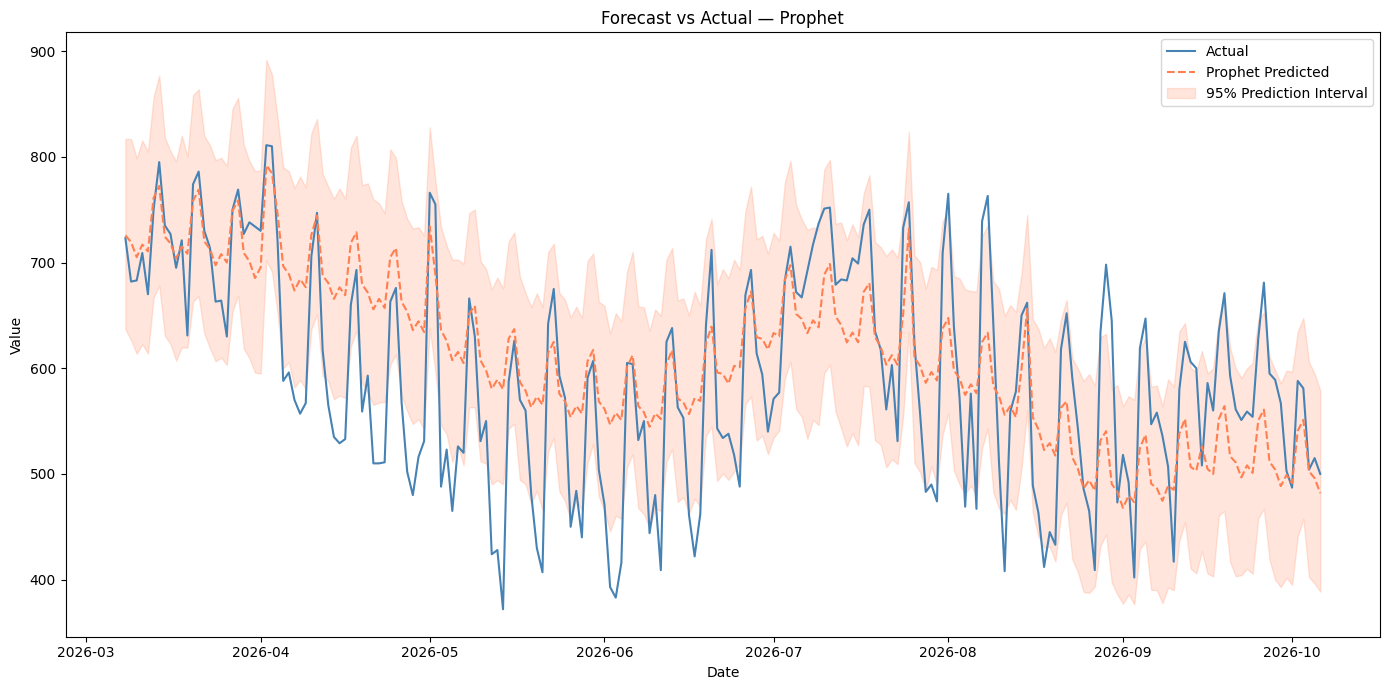

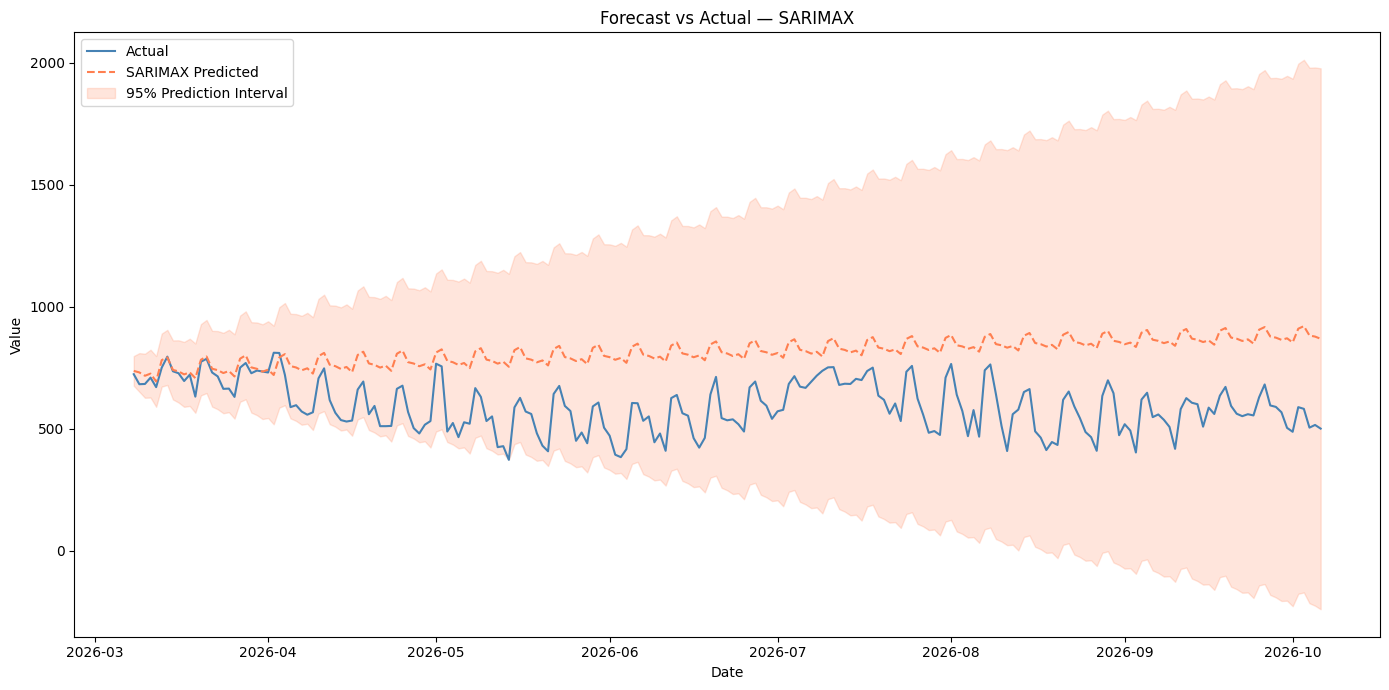

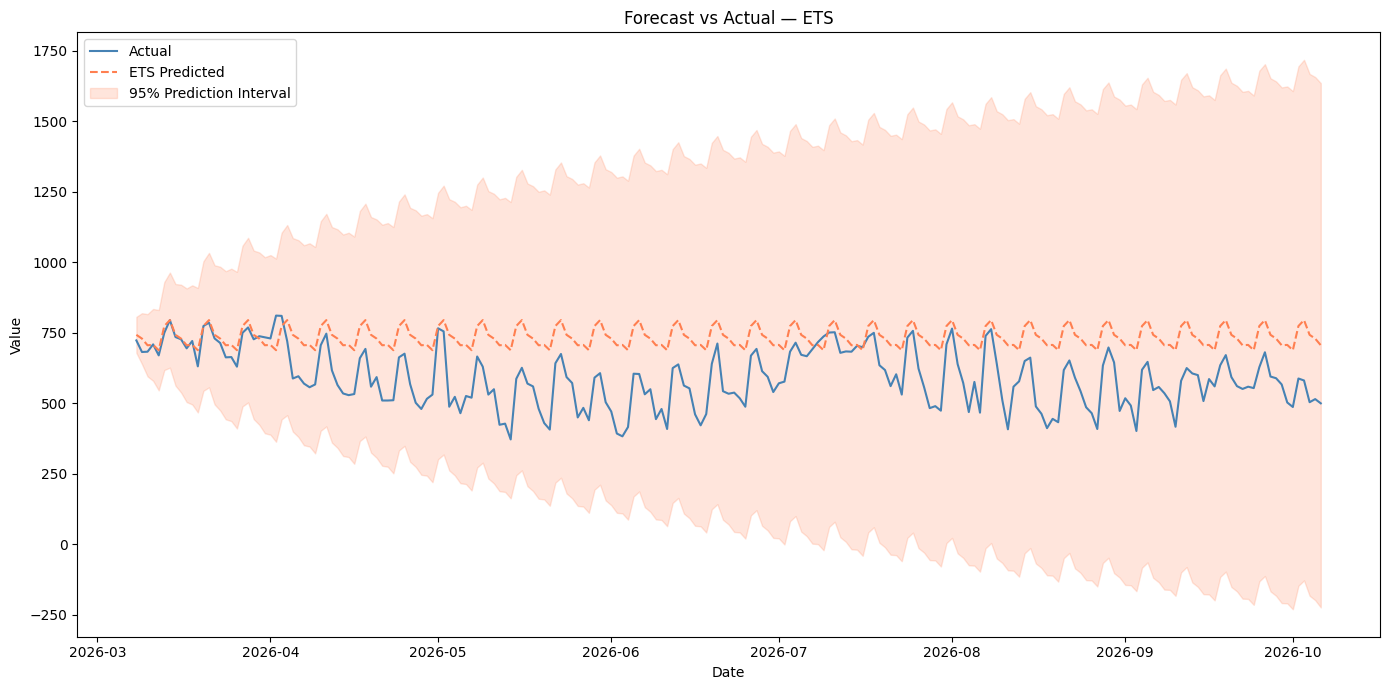

In [13]:
last_week = history_eval[TARGET_COL].values[-7:]
naive_preds = np.array([last_week[i % 7] for i in range(len(test_df))])

# Seasonal naive-365 with damped YoY growth — the yearly seasonal baseline family
# (missing until now; for a seasonal business the 90d horizon crosses high->low
# season, where weekly tiling and recent-level anchors are structurally wrong).
def yoy_growth_s(hist_s, k=90, damp=0.5):
    if len(hist_s) < k + 200:
        return 1.0
    a1 = hist_s.iloc[-k:]
    a0 = hist_s.reindex(a1.index - pd.Timedelta(days=365)).dropna()
    a1v = a1.reindex(a0.index + pd.Timedelta(days=365))
    if len(a0) < 30 or a0.mean() <= 0:
        return 1.0
    return float(np.clip(a1v.mean() / a0.mean(), 0.6, 1.6) ** damp)


def profile4_series(hist_s, dates, weeks=4):
    tail = hist_s.iloc[-weeks * 7:]
    if len(tail) < 7:
        return np.full(len(dates), float(hist_s.mean()))
    prof = tail.groupby(tail.index.dayofweek).mean().reindex(range(7)).fillna(tail.mean())
    return prof.reindex(pd.DatetimeIndex(dates).dayofweek).values


def sn365_series(hist_s, dates):
    dts = pd.DatetimeIndex(dates)
    base = hist_s.reindex(dts - pd.Timedelta(days=365)).values.astype(float)
    preds = base * yoy_growth_s(hist_s)
    return np.where(np.isfinite(base), preds, profile4_series(hist_s, dates))


def sn365_preds(hist_df, dates):
    hist_s = pd.Series(hist_df[TARGET_COL].values, index=pd.DatetimeIndex(hist_df['date']))
    return sn365_series(hist_s, dates)


sn365_test = sn365_preds(history_eval, test_dates)

eval_viz = EvaluationVisualizer()
for name, result in [('Prophet', prophet_result), ('SARIMAX', sarimax_result), ('ETS', ets_result)]:
    fig = eval_viz.plot_forecast(result.actuals, result.predictions, dates=test_dates,
                                 model_name=name,
                                 lower_bound=result.lower_bound, upper_bound=result.upper_bound)
    plt.show()

---
## Section 5: ML Models — libros como covariantes forward-known

Protocolo 3 pasos: (1) ES en val, (2) refit historia pre-test, (3) recursiva con
**covariantes por fecha**: `available_rooms` (último valor) y `rotb_d90/180/365`
(valor por fecha desde los libros actuales).

In [14]:
FUTURE_KNOWN = [AVAIL_COL]

def fit_gbm_honest(model_obj, name):
    print(f"Training {name} (ES on val)...")
    model_obj.fit(train_feat, target_col=TARGET_COL, date_col='date',
                  feature_cols=feature_cols_ml, val_df=val_feat)
    print(f"  best_iteration={model_obj.best_iteration()}")
    model_obj.frozen_iteration = model_obj.best_iteration() or 1000

    hist_feat = prepare_features(history_eval)
    model_obj.final_refit(hist_feat, target_col=TARGET_COL, date_col='date',
                          feature_cols=feature_cols_ml)

    preds = recursive_forecast(
        model_obj, history_eval, test_dates,
        target_col=TARGET_COL, date_col='date', feature_cols=feature_cols_ml,
        feature_engineer=pipeline.feature_engineer,
        holiday_engineer=pipeline.holiday_engineer,
        future_known_cols=FUTURE_KNOWN,
        future_covariates=books_covariates(test_dates),
    )
    print(f"  {name}: {len(preds)} predicciones recursivas")
    return preds

# --- Tuning (objective = recursive val MAE, with books covariates) ---
lgbm_base = {k: v for k, v in LightGBMForecaster().params.items()
             if k not in ('early_stopping_rounds', 'categorical_features')}
def suggest_lgbm(t):
    return {'num_leaves': t.suggest_int('num_leaves', 16, 128),
            'learning_rate': t.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'min_child_samples': t.suggest_int('min_child_samples', 5, 60),
            'feature_fraction': t.suggest_float('feature_fraction', 0.6, 1.0),
            'lambda_l1': t.suggest_float('lambda_l1', 1e-3, 10.0, log=True)}
tuned_lgbm = tune_gbm(LightGBMForecaster, suggest_lgbm, lgbm_base,
                      train_feat, val_feat, pre_val_history, val_dates_t, val_actuals_t,
                      feature_cols_ml, pipeline.feature_engineer, pipeline.holiday_engineer,
                      prepare_features, target_col=TARGET_COL, n_trials=25, seed=SEED,
                      future_known_cols=FUTURE_KNOWN, future_covariates=val_cov)

xgb_base = {k: v for k, v in XGBoostForecaster().params.items() if k != 'early_stopping_rounds'}
def suggest_xgb(t):
    return {'max_depth': t.suggest_int('max_depth', 3, 10),
            'learning_rate': t.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'subsample': t.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': t.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': t.suggest_int('min_child_weight', 1, 20)}
tuned_xgb = tune_gbm(XGBoostForecaster, suggest_xgb, xgb_base,
                     train_feat, val_feat, pre_val_history, val_dates_t, val_actuals_t,
                     feature_cols_ml, pipeline.feature_engineer, pipeline.holiday_engineer,
                     prepare_features, target_col=TARGET_COL, n_trials=25, seed=SEED,
                     future_known_cols=FUTURE_KNOWN, future_covariates=val_cov)

cat_base = {k: v for k, v in CatBoostForecaster().params.items()
            if k not in ('early_stopping_rounds', 'cat_features')}
def suggest_cat(t):
    return {'depth': t.suggest_int('depth', 4, 10),
            'learning_rate': t.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'l2_leaf_reg': t.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True)}
tuned_cat = tune_gbm(CatBoostForecaster, suggest_cat, cat_base,
                     train_feat, val_feat, pre_val_history, val_dates_t, val_actuals_t,
                     feature_cols_ml, pipeline.feature_engineer, pipeline.holiday_engineer,
                     prepare_features, target_col=TARGET_COL, n_trials=25, seed=SEED,
                     future_known_cols=FUTURE_KNOWN, future_covariates=val_cov)
print("Tuning listo (3 familias, objetivo recursivo con libros)")

src.forecasting.models.ml.lgbm_model - INFO - LightGBM fitted in 0.12 sec, best iteration: 53


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 45 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rotb_d365': 214 (20.80%) — action: flag


src.forecasting.models.ml.lgbm_model - INFO - LightGBM final refit: 53 estimators on 1029 rows.


...

src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 150/212 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 200/212 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 212 steps (incremental path)


src.forecasting.models.tuning - INFO - Tuning CatBoostForecaster: best recursive val MAE=53.0767 over 25 trials


Tuning listo (3 familias, objetivo recursivo con libros)


In [15]:
lgbm_params = {k: v for k, v in tuned_lgbm.items()
               if k not in ('early_stopping_rounds', 'categorical_features')}
lgbm = LightGBMForecaster(params=lgbm_params, early_stopping_rounds=50)
lgbm_preds = fit_gbm_honest(lgbm, 'LightGBM')

Training LightGBM (ES on val)...


src.forecasting.models.ml.lgbm_model - INFO - LightGBM fitted in 0.35 sec, best iteration: 295


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 45 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rotb_d365': 433 (34.70%) — action: flag


...

src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 100/213 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 150/213 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 200/213 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 213 steps (incremental path)


  LightGBM: 213 predicciones recursivas


In [16]:
xgb_params = {k: v for k, v in tuned_xgb.items() if k != 'early_stopping_rounds'}
xgb = XGBoostForecaster(params=xgb_params, early_stopping_rounds=50)
xgb_preds = fit_gbm_honest(xgb, 'XGBoost')

Training XGBoost (ES on val)...


src.forecasting.models.ml.xgb_model - INFO - XGBoost fitted in 0.93 sec.


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 45 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rotb_d365': 433 (34.70%) — action: flag


...

src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 100/213 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 150/213 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 200/213 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 213 steps (incremental path)


  XGBoost: 213 predicciones recursivas


In [17]:
cat_params = {k: v for k, v in tuned_cat.items()
               if k not in ('early_stopping_rounds', 'cat_features')}
cat = CatBoostForecaster(params=cat_params, early_stopping_rounds=50)
cat_preds = fit_gbm_honest(cat, 'CatBoost')

Training CatBoost (ES on val)...


src.forecasting.models.ml.catboost_model - INFO - CatBoost fitted in 0.48 sec.


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 45 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rotb_d365': 433 (34.70%) — action: flag


...

src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 100/213 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 150/213 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 200/213 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 213 steps (incremental path)


  CatBoost: 213 predicciones recursivas


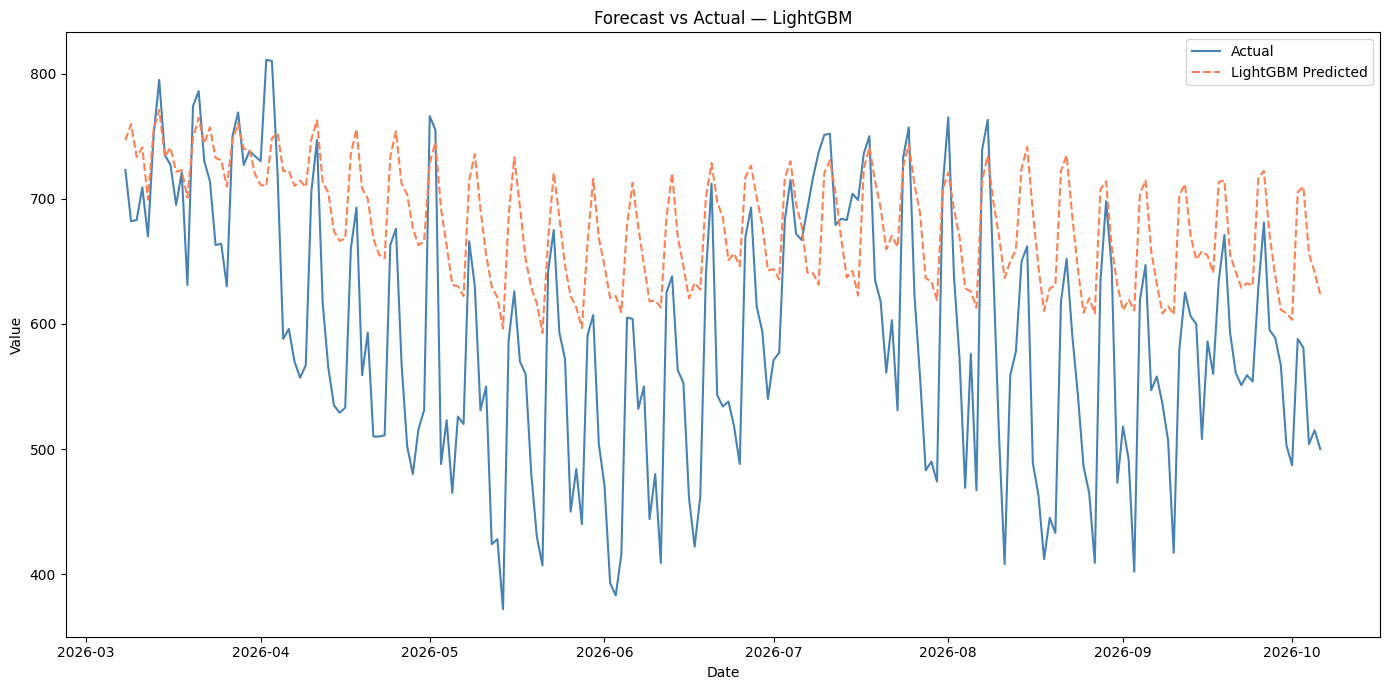

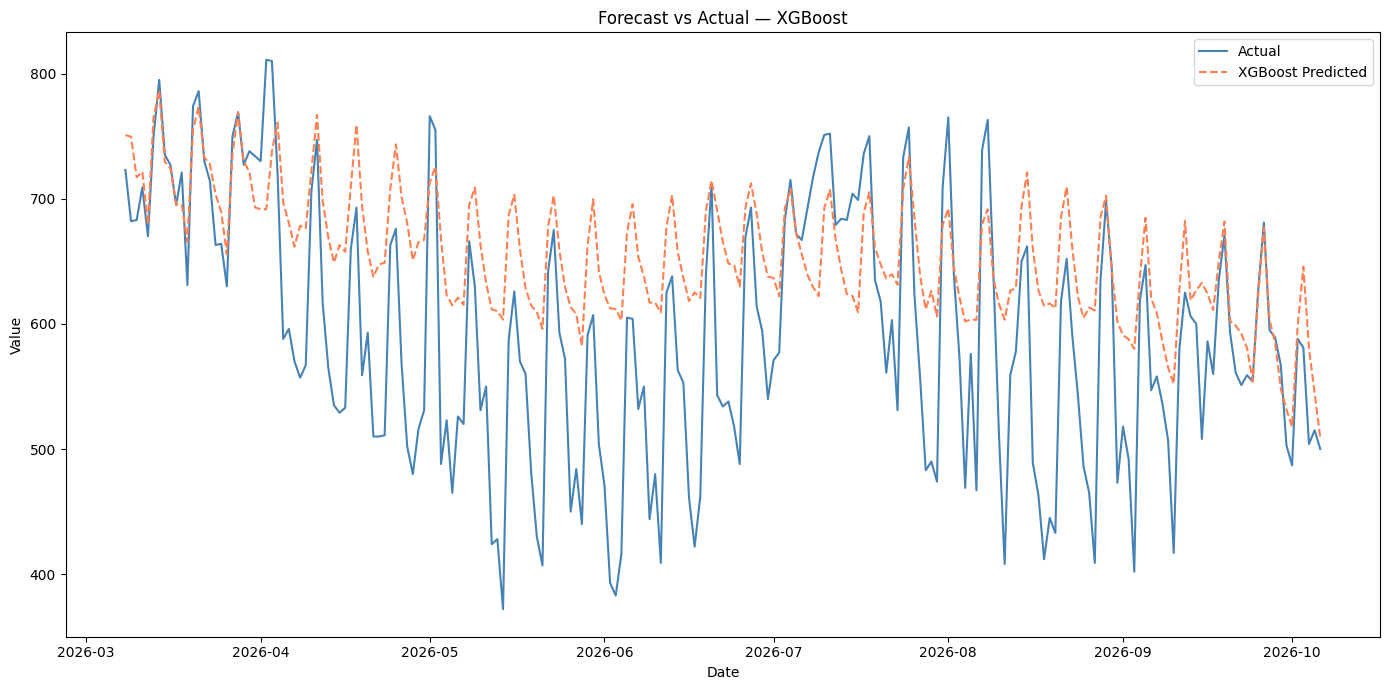

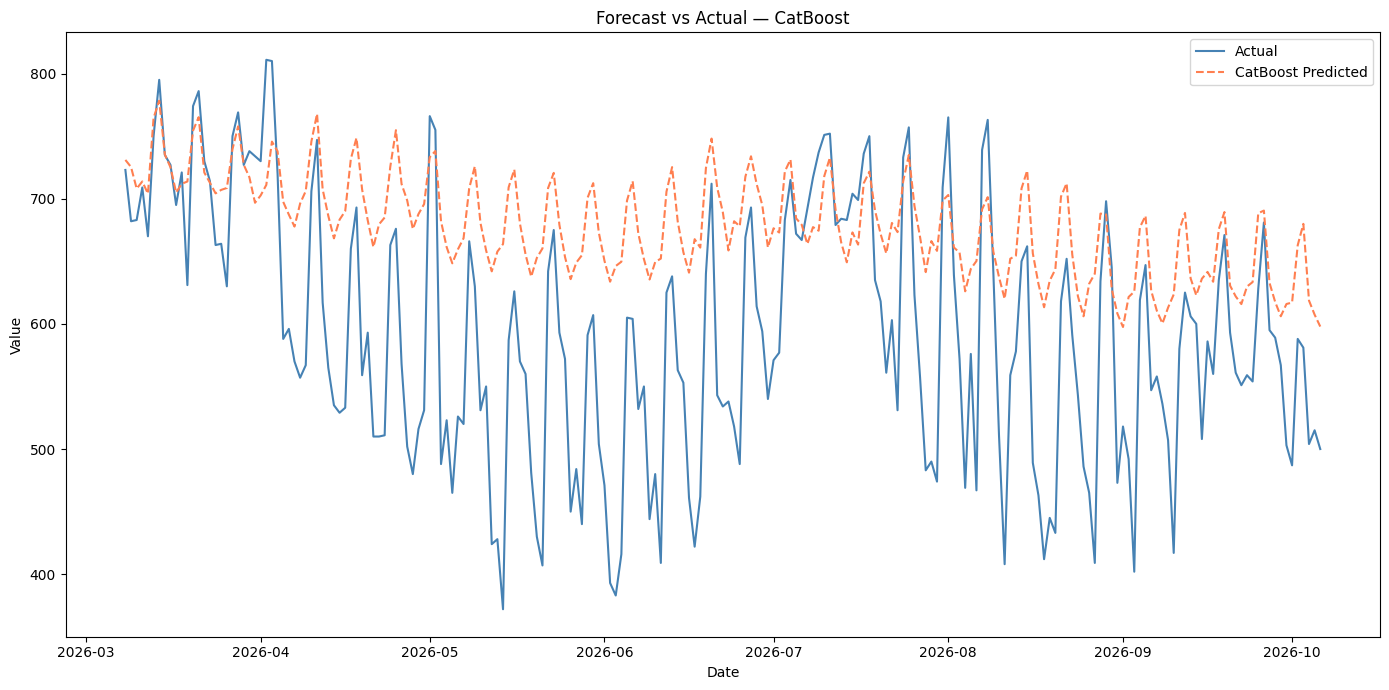

In [18]:
for name, preds in [('LightGBM', lgbm_preds), ('XGBoost', xgb_preds), ('CatBoost', cat_preds)]:
    fig = eval_viz.plot_forecast(actuals_test, preds, dates=test_dates, model_name=name)
    plt.show()

---
## Section 6: Deep Learning (PatchTST; TimesFM excluido honestamente en Windows)

In [19]:
try:
    import timesfm  # noqa: F401
    TIMESFM_AVAILABLE = True
    print("TimesFM available.")
except ImportError:
    TIMESFM_AVAILABLE = False
    print("TimesFM NOT available (Windows/JAX) -> excluido; su fallback jamas se reporta bajo su nombre.")

TimesFM NOT available (Windows/JAX) -> excluido; su fallback jamas se reporta bajo su nombre.


In [20]:
pt_cfg = CONFIG['models']['dl']['patchtst']
patchtst = PatchTSTForecaster(
    patch_len=pt_cfg['patch_len'], stride=pt_cfg['stride'],
    d_model=pt_cfg['d_model'], n_heads=pt_cfg['n_heads'],
    n_layers=pt_cfg['n_layers'], epochs=pt_cfg['epochs'],
    batch_size=pt_cfg['batch_size'], patience=pt_cfg['patience'],
    context_len=256, horizon=30,
)
n_val_pt = max(60, int(len(history_eval) * 0.10))
h_series = history_eval[['date', TARGET_COL]]
patchtst.fit(h_series.iloc[:-n_val_pt], target_col=TARGET_COL, date_col='date',
             val_df=h_series.iloc[-n_val_pt:])
patchtst_result = patchtst.predict(test_df, target_col=TARGET_COL, date_col='date',
                                    context_df=h_series)
print(f"PatchTST: {len(patchtst_result.predictions)} predicciones")

src.forecasting.models.dl.patchtst_model - INFO - Early stopping at epoch 9


src.forecasting.models.dl.patchtst_model - INFO - PatchTST fitted in 6.49 sec.


PatchTST: 213 predicciones


---
## Section 7: Comparación + sesgo + backtesting + significancia

In [21]:
evaluator = Evaluator()
all_results = {
    'SeasonalNaive': (actuals_test, naive_preds),
    'SeasonalNaive365': (actuals_test, sn365_test),
    'Prophet': (actuals_test, prophet_result.predictions),
    'SARIMAX': (actuals_test, sarimax_result.predictions),
    'ETS': (actuals_test, ets_result.predictions),
    'LightGBM': (actuals_test, lgbm_preds),
    'XGBoost': (actuals_test, xgb_preds),
    'CatBoost': (actuals_test, cat_preds),
    'PatchTST': (actuals_test, patchtst_result.predictions),
}
metrics_results = evaluator.compute_all_metrics(all_results, split='test', naive_forecast=naive_preds)
comparison_df = evaluator.comparison_table(metrics_results)
print("=== Model Comparison — Test (multi-paso, room nights, datos reales-schema) ===")
display(comparison_df.round(2))

src.forecasting.evaluation.evaluator - INFO - SeasonalNaive (test): MAE=134.69, RMSE=154.76, MAPE=25.50%, WAPE=22.74%, Bias=+21.78% (194 over / 18 under)


src.forecasting.evaluation.evaluator - INFO - SeasonalNaive365 (test): MAE=68.76, RMSE=89.62, MAPE=11.71%, WAPE=11.61%, Bias=-2.51% (91 over / 122 under)


src.forecasting.evaluation.evaluator - INFO - Prophet (test): MAE=63.43, RMSE=78.53, MAPE=11.82%, WAPE=10.71%, Bias=+3.02% (115 over / 98 under)


src.forecasting.evaluation.evaluator - INFO - SARIMAX (test): MAE=222.63, RMSE=248.13, MAPE=41.81%, WAPE=37.58%, Bias=+37.40% (209 over / 4 under)


src.forecasting.evaluation.evaluator - INFO - ETS (test): MAE=145.01, RMSE=166.16, MAPE=27.67%, WAPE=24.48%, Bias=+24.00% (203 over / 10 under)


...

src.forecasting.evaluation.evaluator - INFO - XGBoost (test): MAE=77.46, RMSE=96.59, MAPE=15.01%, WAPE=13.08%, Bias=+10.65% (173 over / 40 under)


src.forecasting.evaluation.evaluator - INFO - CatBoost (test): MAE=95.80, RMSE=116.78, MAPE=18.66%, WAPE=16.17%, Bias=+14.58% (178 over / 35 under)


src.forecasting.evaluation.evaluator - INFO - PatchTST (test): MAE=89.14, RMSE=108.94, MAPE=15.05%, WAPE=15.05%, Bias=-4.91% (91 over / 122 under)


=== Model Comparison — Test (multi-paso, room nights, datos reales-schema) ===


,N,MAE,RMSE,MAPE,sMAPE,MASE,WAPE,Bias%,Over_days,Under_days
Model,,,,,,,,,,
SeasonalNaive,213,134.69,154.76,25.50,21.60,1.00,22.74,21.78,194,18
SeasonalNaive365,213,68.76,89.62,11.71,12.00,0.51,11.61,-2.51,91,122
Prophet,213,63.43,78.53,11.82,11.15,0.47,10.71,3.02,115,98
SARIMAX,213,222.63,248.13,41.81,32.71,1.65,37.58,37.40,209,4
ETS,213,145.01,166.16,27.67,23.10,1.08,24.48,24.00,203,10
LightGBM,213,96.29,112.61,18.47,16.24,0.71,16.26,14.74,184,29
XGBoost,213,77.46,96.59,15.01,13.34,0.58,13.08,10.65,173,40
CatBoost,213,95.80,116.78,18.66,16.18,0.71,16.17,14.58,178,35
PatchTST,213,89.14,108.94,15.05,15.23,0.66,15.05,-4.91,91,122


In [22]:
comparison = evaluator.compare_models(metrics_results, primary_metric='MAE')
best_name = comparison.best_model
print(f"Best (by MAE): {best_name}")
print(f"Rankings: {comparison.rankings.get('MAE')}")

ranked = comparison.rankings.get('MAE', [])
dm_rows = []
for other in ranked[1:]:
    dm = evaluator.diebold_mariano_test(actuals_test, all_results[best_name][1],
                                         all_results[other][1], h=7, power=1)
    dm_rows.append({'Competitor': other, 'DM': dm['dm_statistic'], 'p-value': dm['p_value'],
                    'Better & significant': bool(dm['significant'] and dm['dm_statistic'] < 0)})
dm_df = pd.DataFrame(dm_rows).set_index('Competitor')
display(dm_df)

src.forecasting.evaluation.evaluator - INFO - Best model by MAE: Prophet


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-1.0757, p=0.2833 — Not significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-2.6633, p=0.0083 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-2.6727, p=0.0081 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-5.1149, p=0.0000 — Significant


...

src.forecasting.evaluation.evaluator - INFO - DM test: stat=-7.6879, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-8.1679, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-10.2798, p=0.0000 — Significant


Best (by MAE): Prophet
Rankings: ['Prophet', 'SeasonalNaive365', 'XGBoost', 'PatchTST', 'CatBoost', 'LightGBM', 'SeasonalNaive', 'ETS', 'SARIMAX']


,DM,p-value,Better & significant
Competitor,,,
SeasonalNaive365,-1.0757,0.2833,False
XGBoost,-2.6633,0.0083,True
PatchTST,-2.6727,0.0081,True
CatBoost,-5.1149,0.0000,True
LightGBM,-6.4090,0.0000,True
SeasonalNaive,-7.6879,0.0000,True
ETS,-8.1679,0.0000,True
SARIMAX,-10.2798,0.0000,True


In [23]:
best_row = comparison_df.loc[best_name]
over, under = int(best_row['Over_days']), int(best_row['Under_days'])
direction = 'OVER-forecasts' if best_row['Bias%'] > 0 else 'UNDER-forecasts'
print(f"Bias ({best_name}): {best_row['Bias%']:+.2f}% -> {direction} ({over}/{under} dias)")

err_df = pd.DataFrame({'date': test_dates, 'actual': actuals_test, 'pred': all_results[best_name][1]})
err_df['abs_error'] = (err_df['actual'] - err_df['pred']).abs()
err_df['pct_error'] = err_df['abs_error'] / err_df['actual'] * 100
err_df['dow'] = err_df['date'].dt.day_name()
dow_table = err_df.groupby('dow').agg(
    days=('abs_error', 'size'), MAE=('abs_error', 'mean'), MAPE_pct=('pct_error', 'mean'),
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
display(dow_table.round(2))
print(f"MAE finde: {err_df[err_df['date'].dt.dayofweek >= 5]['abs_error'].mean():.1f} vs "
      f"entre-semana: {err_df[err_df['date'].dt.dayofweek < 5]['abs_error'].mean():.1f}")

Bias (Prophet): +3.02% -> OVER-forecasts (115/98 dias)


,days,MAE,MAPE_pct
dow,,,
Monday,31,49.88,9.03
Tuesday,31,81.21,16.68
Wednesday,30,74.18,14.97
Thursday,30,91.02,18.93
Friday,30,43.48,6.53
Saturday,30,51.32,7.37
Sunday,31,53.11,9.24


MAE finde: 52.2 vs entre-semana: 67.9


---
### Backtesting rolling-origin — estabilidad del ranking

6 ventanas × 90d; cada fold solo ve historia estrictamente previa; hiperparámetros
congelados del tuning. Los residuales del ganador alimentan las bandas conformales.

In [24]:
BT_HORIZON = HORIZON
bt_folds = make_rolling_folds(test_start - pd.Timedelta(days=1), n_folds=6,
                              horizon_days=BT_HORIZON, step_days=45)

def _bt_stat(cls, **kw):
    def f(hist, dates):
        m = cls(**kw)
        m.fit(hist[['date', TARGET_COL]], target_col=TARGET_COL, date_col='date')
        return m.predict(pd.DataFrame({'date': dates}), target_col=TARGET_COL,
                         date_col='date').predictions
    return f

def _bt_gbm(cls, params, iters_key, iters):
    def f(hist, dates):
        m = cls(params={**params, iters_key: int(iters)}, early_stopping_rounds=50)
        m.fit(prepare_features(hist), target_col=TARGET_COL, date_col='date',
              feature_cols=feature_cols_ml)
        return recursive_forecast(
            m, hist, dates, target_col=TARGET_COL, date_col='date',
            feature_cols=feature_cols_ml,
            feature_engineer=pipeline.feature_engineer,
            holiday_engineer=pipeline.holiday_engineer,
            future_known_cols=FUTURE_KNOWN, future_covariates=books_covariates(dates),
        )
    return f

def _bt_patchtst(hist, dates):
    m = PatchTSTForecaster(patch_len=pt_cfg['patch_len'], stride=pt_cfg['stride'],
                           d_model=pt_cfg['d_model'], n_heads=pt_cfg['n_heads'],
                           n_layers=pt_cfg['n_layers'], epochs=pt_cfg['epochs'],
                           batch_size=pt_cfg['batch_size'], patience=pt_cfg['patience'],
                           context_len=256, horizon=30)
    h = hist[['date', TARGET_COL]]
    nv = max(60, int(len(h) * 0.10))
    m.fit(h.iloc[:-nv], target_col=TARGET_COL, date_col='date', val_df=h.iloc[-nv:])
    return m.predict(pd.DataFrame({'date': dates}), target_col=TARGET_COL,
                     date_col='date', context_df=h).predictions

def _bt_naive(hist, dates):
    tail = hist[TARGET_COL].values[-7:]
    return np.array([tail[i % 7] for i in range(len(dates))])

gbm_params_by_name = {'LightGBM': (LightGBMForecaster, lgbm_params, 'n_estimators'),
                      'XGBoost': (XGBoostForecaster, xgb_params, 'n_estimators'),
                      'CatBoost': (CatBoostForecaster, cat_params, 'iterations')}
frozen_iters = {'LightGBM': lgbm.frozen_iteration, 'XGBoost': xgb.frozen_iteration,
                'CatBoost': cat.frozen_iteration}
bt_forecasters = {
    'SeasonalNaive': _bt_naive,
    'SeasonalNaive365': lambda hist, dates: sn365_preds(hist, dates),
    'Prophet': _bt_stat(ProphetForecaster, **prophet_best),
    'SARIMAX': _bt_stat(SARIMAXForecaster, seasonal_periods=[7], stepwise=True),
    'ETS': _bt_stat(ETSForecaster, seasonal_periods=7, damped_trend=True, auto_select=True),
    'PatchTST': _bt_patchtst,
}
for name, (cls, params, iters_key) in gbm_params_by_name.items():
    bt_forecasters[name] = _bt_gbm(cls, params, iters_key, frozen_iters[name])

bt_result = rolling_origin_backtest(df_agg, bt_forecasters, bt_folds, target_col=TARGET_COL)
print("=== MAE por ventana ===")
display(bt_result.mae_table.round(1))
display(pd.DataFrame({'rango_medio': bt_result.mean_rank, 'victorias': bt_result.wins}))
print(f"{best_name}: rango medio {bt_result.mean_rank[best_name]:.1f}/8 | "
      f"{int(bt_result.wins[best_name])}/{len(bt_folds)} victorias")

cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


cmdstanpy - DEBUG - TBB already found in load path


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpuhzp61om\78jp331i.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpuhzp61om\eqs1ribw.json


cmdstanpy - DEBUG - idx 0


...

src.forecasting.evaluation.backtesting - INFO - Backtest fold 5: window 2025-03-08 -> 2026-03-07 | history ends 2025-03-07 | 9 models


=== MAE por ventana ===


fold,0,1,2,3,4,5
SeasonalNaive,78.4,121.0,111.5,75.4,117.7,90.5
SeasonalNaive365,256.4,230.7,199.6,170.6,155.1,74.4
Prophet,371.6,326.2,335.2,306.2,245.1,75.5
SARIMAX,84.9,341.8,86.1,271.0,374.7,86.4
ETS,88.2,123.3,79.7,74.7,139.0,85.3
PatchTST,109.2,97.5,86.4,78.2,82.4,92.6
LightGBM,60.0,91.8,56.5,53.5,49.4,56.6
XGBoost,61.8,67.9,53.3,48.7,47.5,54.0
CatBoost,84.5,68.3,67.6,56.3,50.8,52.7


,rango_medio,victorias
CatBoost,2.666667,1
ETS,5.333333,0
LightGBM,2.166667,1
PatchTST,6.000000,0
Prophet,8.000000,0
SARIMAX,7.166667,0
SeasonalNaive,5.500000,0
SeasonalNaive365,6.833333,0
XGBoost,1.333333,4


Prophet: rango medio 8.0/8 | 0/6 victorias


---
## Section 8: Pronóstico 90 días con libros actuales + bandas + por propiedad

El ganador se reentrena con TODA la historia y pronostica con:
- **Libros actuales** (rotb_d90/180/365 de las reservas vigentes) como covariantes
- **Techo de capacidad** oficial del inventario
- **Bandas conformales** (residuales del backtesting) con cobertura reportada
- **Por propiedad** para staffing: modelo propio por score compuesto (MAE+|sesgo|) en 12 folds pre-test — candidatos Prophet/SN365/Books/Blend — + guardas (short/stale/cold)
- **Bottom-up operacional**: la suma por propiedad es el número del portafolio (inmune al cambio de composición); el top-down queda como cross-check

In [25]:
last_observed = full_history['date'].max()
future_dates = pd.date_range(last_observed + pd.Timedelta(days=1), periods=HORIZON, freq='D')
future_capacity_s = capacity.groupby('business_date')['available_rooms'].sum().sort_index()
if last_observed in future_capacity_s.index:
    last_cap = float(future_capacity_s.loc[last_observed])
else:
    last_cap = float(future_capacity_s.iloc[-1])
future_capacity = pd.Series(np.full(HORIZON, last_cap))
future_cov = books_covariates(future_dates)

print(f"Best: {best_name} | {HORIZON} dias desde {future_dates[0].date()} | capacidad {last_cap:.0f}")

gbm_map = {'LightGBM': lgbm, 'XGBoost': xgb, 'CatBoost': cat}
future_lo = future_hi = None

if best_name in gbm_map:
    model_obj = gbm_map[best_name]
    full_feat = prepare_features(full_history)
    model_obj.final_refit(full_feat, target_col=TARGET_COL, date_col='date',
                          feature_cols=feature_cols_ml)
    raw_future = recursive_forecast(
        model_obj, full_history, future_dates,
        target_col=TARGET_COL, date_col='date', feature_cols=feature_cols_ml,
        feature_engineer=pipeline.feature_engineer,
        holiday_engineer=pipeline.holiday_engineer,
        future_known_cols=FUTURE_KNOWN, future_covariates=future_cov,
    )
elif best_name in ('SeasonalNaive', 'SeasonalNaive365'):
    if best_name == 'SeasonalNaive':
        lw = full_history[TARGET_COL].values[-7:]
        raw_future = np.array([lw[i % 7] for i in range(HORIZON)])
    else:
        raw_future = sn365_preds(full_history, future_dates)
elif best_name in ('Prophet', 'SARIMAX', 'ETS'):
    cls = {'Prophet': ProphetForecaster, 'SARIMAX': SARIMAXForecaster, 'ETS': ETSForecaster}[best_name]
    kw = prophet_best if best_name == 'Prophet' else (
        {'seasonal_periods': [7], 'stepwise': True} if best_name == 'SARIMAX'
        else {'seasonal_periods': 7, 'damped_trend': True, 'auto_select': True})
    fm = cls(**kw)
    fm.fit(full_history[['date', TARGET_COL]], target_col=TARGET_COL, date_col='date')
    fr = fm.predict(pd.DataFrame({'date': future_dates}), target_col=TARGET_COL, date_col='date')
    raw_future, future_lo, future_hi = fr.predictions, fr.lower_bound, fr.upper_bound
else:  # PatchTST
    fm = PatchTSTForecaster(patch_len=pt_cfg['patch_len'], stride=pt_cfg['stride'],
                            d_model=pt_cfg['d_model'], n_heads=pt_cfg['n_heads'],
                            n_layers=pt_cfg['n_layers'], epochs=pt_cfg['epochs'],
                            batch_size=pt_cfg['batch_size'], patience=pt_cfg['patience'],
                            context_len=256, horizon=30)
    nv = max(60, int(len(full_history) * 0.10))
    fh = full_history[['date', TARGET_COL]]
    fm.fit(fh.iloc[:-nv], target_col=TARGET_COL, date_col='date', val_df=fh.iloc[-nv:])
    fr = fm.predict(pd.DataFrame({'date': future_dates}), target_col=TARGET_COL,
                    date_col='date', context_df=fh)
    raw_future = fr.predictions

assert len(raw_future) == HORIZON and not np.isnan(np.asarray(raw_future, dtype=float)).any()

future_series = pd.Series(np.asarray(raw_future, dtype=float), index=future_dates)
future_preds, cap_report = apply_capacity_ceiling(future_series, future_capacity)
future_occ = implied_occupancy(future_preds, future_capacity)

# Conformal (D3 enmendada 2026-10-08): las bandas top-down de 365d se RETIRAN —
# todo fold del portafolio entrena a traves del cambio de composicion 2024
# (150->660 rn/dia) y sobre-predice -100..-513/dia (medido), sesgo que el modelo
# desplegado no comparte (exchangeability conformal rota a este horizonte).
# Las bandas operacionales son las bottom-up (celda siguiente) con folds
# representativos. El cross-check top-down queda como punto + brecha.
ALPHA = 0.2
folds12 = make_rolling_folds(test_start - pd.Timedelta(days=1), n_folds=12,
                             horizon_days=HORIZON, step_days=30)

print(f"Total {HORIZON}d: {future_preds.sum():,.0f} room nights | media {future_preds.mean():.1f}/dia")
print(f"Ocupacion implícita: {future_occ.mean():.1%} | dias recortados: {len(cap_report)}")
print("Bandas top-down 365d retiradas (D3 enmendada); ver bandas bottom-up operacionales")

cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


cmdstanpy - DEBUG - TBB already found in load path


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpuhzp61om\rhpyq959.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpuhzp61om\gntorazo.json


cmdstanpy - DEBUG - idx 0


...

Best: Prophet | 365 dias desde 2026-10-07 | capacidad 968


07:31:50 - cmdstanpy - INFO - Chain [1] done processing


cmdstanpy - INFO - Chain [1] done processing


src.forecasting.models.statistical.prophet_model - INFO - Prophet fitted in 0.26 seconds on 1461 rows.


Total 365d: 234,679 room nights | media 643.0/dia
Ocupacion implícita: 66.4% | dias recortados: 0
Bandas top-down 365d retiradas (D3 enmendada); ver bandas bottom-up operacionales


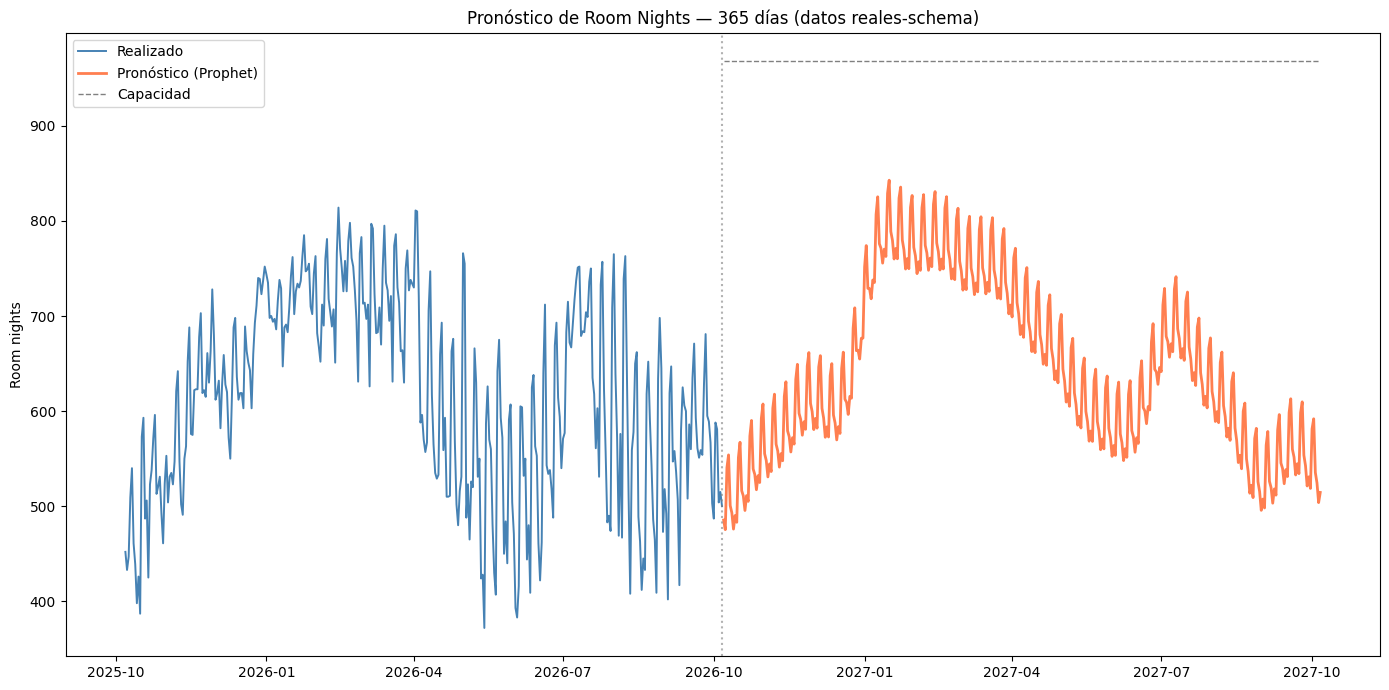

In [26]:
fig, ax = plt.subplots(figsize=(14, 7))
hist_plot = full_history.iloc[-365:]
ax.plot(hist_plot['date'], hist_plot[TARGET_COL], label='Realizado', color='steelblue', lw=1.4)
ax.plot(future_dates, future_preds.values, label=f'Pronóstico ({best_name})', color='coral', lw=2)
# Bandas top-down 365d retiradas (D3 enmendada); las operacionales son bottom-up
ax.plot(future_dates, future_capacity, label='Capacidad', color='gray', ls='--', lw=1)
ax.axvline(x=last_observed, color='gray', ls=':', alpha=0.6)
ax.set_title(f'Pronóstico de Room Nights — {HORIZON} días (datos reales-schema)')
ax.set_ylabel('Room nights'); ax.legend()
fig.tight_layout(); plt.show()

---
### Por propiedad: ganador por folds + guardas honestas + bottom-up operacional

Operaciones hace staffing por propiedad, así que cada propiedad recibe:

- **Modelo propio** seleccionado en 12 folds **pre-test** con score compuesto
  **MAE + |sesgo|** (para staffing, el sesgo sistemático es costoso). Candidatos:
  grid de Prophet, SN365(+crecimiento YoY amortiguado), ancla de libros
  (rotb_d90 × completitud), Blend 50/50 y SN7 como piso (con margen ≥10%):
  el test queda como evaluación pura, jamás para elegir
- **Guard de historia corta** (<120 días de historia de ajuste → SeasonalNaive con
  flag): evita explosiones tipo SJO (+896% de sesgo con 60 días de Prophet)
- **Stale/cold-start** (red de seguridad): sin demanda reciente o sin historia →
  estimado desde libros × completitud pickup aprendida, con flag explícito

El **bottom-up** (suma de per-propiedad) es el pronóstico **operacional** del
portafolio: inmune al cambio de composición (hoteles unidos en 2023/2024/2026),
gana al top-down en test y es lo que operaciones necesita de todas formas. El
top-down queda como cross-check honesto. Bandas: conformal del ganador con 12
ventanas post-2024 y, para el bottom-up, Monte Carlo fold-alineado con los
residuales propios de cada propiedad (composición-correcto por construcción).

Las propiedades **congeladas** (`frozen_properties` en config) se excluyen desde
la Sección 1.

In [27]:
# --- Per-property: composite-score selection, seasonal & books candidates ---
# v3.5 specialist evidence (2026-10-08): fold-MAE-only selection ignored systematic
# drift (+8.93% bottom-up test bias). Composite score = fold MAE + |fold MBE|
# (both rooms/day) reflects staffing costs. Candidates (fold evidence ONLY):
#   Prophet grid | SN7 floor (>=10% fold-MAE margin to displace others) |
#   SN365(+damped YoY growth) | BooksAnchor (rotb_d90 x completion) |
#   Blend50 (0.5*Prophet + 0.5*SN365)
# Short-history guard (<120 fit days): BooksAnchor if books cover the window,
# else weekly tiling — standard RM practice for opening hotels. Stale/cold
# safety nets unchanged. The test window is NEVER used for selection.
MIN_FIT_DAYS = 120
PP_GRID = [(cps, sps) for cps in (0.01, 0.05, 0.1) for sps in (1.0, 10.0)]
global_last = demand['stay_date'].max()
STALE_DAYS = 7

per_hotel_rows, per_hotel_future = [], []
per_prop_model, res_by_prop, per_prop_predfn, short_pools, completition = {}, {}, {}, {}, {}
stale_props_display = []
median_completion = np.nan


def prop_series(prop):
    g = demand[demand['property'] == prop].groupby('stay_date')['rooms_sold'].sum().sort_index()
    gi = pd.date_range(g.index.min(), g.index.max(), freq='D')
    return g.reindex(gi).ffill().bfill()


def sn7_preds(hist_vals, n):
    tail = np.asarray(hist_vals)[-7:]
    return np.array([tail[i % 7] for i in range(n)])


def prophet_pp(params, hist, dates):
    m = ProphetForecaster(**params)
    m.fit(pd.DataFrame({'date': pd.DatetimeIndex(hist.index), TARGET_COL: hist.values}),
          target_col=TARGET_COL, date_col='date')
    return m.predict(pd.DataFrame({'date': pd.DatetimeIndex(dates)}),
                     target_col=TARGET_COL, date_col='date').predictions


def books_anchor_prop(pick_g, hist_s, dates):
    """rotb_d90(t) x RECENT completion (last 120d of hist — ramp-robust); P4 fallback."""
    bh = pick_g[rotb_cols_ml[0]].reindex(hist_s.index)
    wb = pd.DataFrame({'y': hist_s.values, 'b': bh.values}).dropna().tail(120)
    comp = float((wb['y'] / wb['b']).median()) if len(wb) else np.nan
    books = pick_g[rotb_cols_ml[0]].reindex(pd.DatetimeIndex(dates))
    preds = books.values * comp if np.isfinite(comp) else np.full(len(dates), np.nan)
    return np.where(np.isfinite(preds), preds, profile4_series(hist_s, dates))


# (D7) Selection evidence: the validated 12 x 90-day fold protocol — fold models
# must represent the deployment task; 365-day fold selection drifted to a books x 27x
# completion extrapolation with degraded test outcomes (measured 2026-10-08).
folds_sel = make_rolling_folds(test_start - pd.Timedelta(days=1), n_folds=12,
                               horizon_days=90, step_days=30)

def run_prop_folds(predict_fn, g):
    """Composite fold evidence: (score=MAE+|MBE|, MAE, residuals (n_folds, 90))."""
    errs, mbes, res = [], [], np.full((len(folds_sel), 90), np.nan)
    for i, f in enumerate(folds_sel):
        hist = g[g.index < f.window_start]
        if len(hist) < 60:
            return np.inf, np.inf, None
        win = pd.date_range(f.window_start, f.window_end, freq='D')
        p = predict_fn(hist, win)
        a = g.reindex(win).values
        res[i] = a - p
        errs.append(float(np.nanmean(np.abs(res[i]))))
        mbes.append(float(np.nanmean(p - a)))
    mae_f, mbe_f = float(np.mean(errs)), float(np.mean(mbes))
    return mae_f + abs(mbe_f), mae_f, res


warm_props = [p for p in demand['property'].unique()
              if demand[demand['property'] == p]['stay_date'].nunique() >= cold_min]
cold_props = [p for p in demand['property'].unique() if p not in warm_props]

# Pass 1: pickup-completion factor from fresh actives (stale/cold safety net)
for prop in warm_props:
    g = prop_series(prop)
    pick_g = build_pickup_features(
        pickup[pickup['property'] == prop], LEAD_BUCKETS).set_index('stay_date')
    h_df = pd.DataFrame({'date': g.index, TARGET_COL: g.values})
    h_df[rotb_cols_ml[0]] = pick_g[rotb_cols_ml[0]].reindex(h_df['date']).values
    recent = h_df.dropna(subset=[rotb_cols_ml[0]]).tail(120)
    if len(recent):
        completition[prop] = float((recent[TARGET_COL] / recent[rotb_cols_ml[0]]).median())
fresh_completion = [v for p, v in completition.items()
                     if demand[demand['property'] == p]['stay_date'].max()
                     >= global_last - pd.Timedelta(days=STALE_DAYS)]
if fresh_completion:
    median_completion = float(np.median(fresh_completion))
print(f"Completitud pickup aprendida (frescas): {median_completion:.2f}x")


def books_estimate(pick_g, cap_future):
    books_future = pick_g[rotb_cols_ml[0]].reindex(future_dates).fillna(0.0).values
    est = books_future * (median_completion if np.isfinite(median_completion) else 1.0)
    if not np.isnan(cap_future):
        est = np.minimum(est, cap_future)
    return est


# Pass 2: per-property composite selection -> test eval -> future forecast
bu_test_preds = {}
for prop in warm_props:
    g = prop_series(prop)
    fresh = g.index.max() >= global_last - pd.Timedelta(days=STALE_DAYS)
    status = 'fresh' if fresh else 'stale'
    if not fresh:
        stale_props_display.append(display_name.get(prop, prop))
    pre = g[g.index < test_start]
    h_test_dates = g.index[(g.index >= test_start) & (g.index <= test_df['date'].max())]
    pick_g = build_pickup_features(
        pickup[pickup['property'] == prop], LEAD_BUCKETS).set_index('stay_date')

    # ---- composite selection on pre-test folds (test never touched) ----
    if len(pre) >= MIN_FIT_DAYS:
        s_sn, m_sn, r_sn = run_prop_folds(lambda h, d: sn7_preds(h.values, len(d)), g)
        best_params, s_pb, m_pb, r_pb = None, np.inf, np.inf, None
        for cps, sps in PP_GRID:
            params = {'changepoint_prior_scale': cps, 'seasonality_prior_scale': sps}
            s_f, m_f, r_f = run_prop_folds(
                lambda h, d, _p=params: prophet_pp(_p, h, d), g)
            if s_f < s_pb:
                best_params, s_pb, m_pb, r_pb = params, s_f, m_f, r_f
        s_365, m_365, r_365 = run_prop_folds(lambda h, d: sn365_series(h, d), g)
        s_ba, m_ba, r_ba = run_prop_folds(lambda h, d: books_anchor_prop(pick_g, h, d), g)

        def blend_fn(h, d, _p=best_params):
            return 0.5 * prophet_pp(_p, h, d) + 0.5 * sn365_series(h, d)

        s_bl, m_bl, r_bl = run_prop_folds(blend_fn, g)
        cands = {
            'SN7': (s_sn, m_sn, r_sn, 'SN7', None,
                    lambda h, d: sn7_preds(h.values, len(d))),
            'Prophet': (s_pb, m_pb, r_pb, 'Prophet', best_params,
                        lambda h, d: prophet_pp(best_params, h, d)),
            'SN365': (s_365, m_365, r_365, 'SN365(+g)', None,
                      lambda h, d: sn365_series(h, d)),
            'BA': (s_ba, m_ba, r_ba, 'BooksAnchor', None,
                   lambda h, d: books_anchor_prop(pick_g, h, d)),
            'Blend': (s_bl, m_bl, r_bl, 'Blend(P+SN365)', best_params,
                      lambda h, d: 0.5 * prophet_pp(best_params, h, d)
                      + 0.5 * sn365_series(h, d)),
        }
        best_nm = min((k for k in cands if np.isfinite(cands[k][0])),
                      key=lambda k: cands[k][0])
        # A-priori floor rule: weekly tiling must beat the best alternative by
        # >=10% on fold MAE to be selected for a 90-day seasonal horizon.
        if best_nm == 'SN7':
            m_other = min(cands[k][1] for k in cands
                          if k != 'SN7' and np.isfinite(cands[k][1]))
            if not (m_sn < 0.90 * m_other):
                best_nm = min((k for k in cands if k != 'SN7' and np.isfinite(cands[k][0])),
                              key=lambda k: cands[k][0])
        score, _, res_win, kind, params, pred_fn = cands[best_nm]
        if res_win is not None:
            res_by_prop[prop] = res_win
        per_prop_predfn[prop] = pred_fn
        if kind == 'Prophet':
            per_prop_model[prop] = (
                f"Prophet(cps={params['changepoint_prior_scale']},"
                f"sps={params['seasonality_prior_scale']})")
        elif kind == 'Blend(P+SN365)':
            per_prop_model[prop] = 'Blend(P+SN365)'
        else:
            per_prop_model[prop] = kind
        print(f"{display_name.get(prop, prop)}: {per_prop_model[prop]} "
              f"(score {score:.1f})")
    else:
        # Short-history guard: recent-level anchoring (weekly tiling). BooksAnchor
        # is NOT valid here: completion-ratio stationarity is unverifiable with
        # <120d and ramps violate it (SJO's opening realized/books_d90 ratio ~8x
        # vs portfolio 2.68x — back-loaded booking curve; applying it to future
        # books produced an implausible ~4x-level forecast).
        per_prop_model[prop] = 'SeasonalNaive (guard short-history)'
        pred_fn = lambda h, d: sn7_preds(h.values, len(d))
        if len(pre) > 7:
            short_pools[prop] = (pre.values[7:] - pre.values[:-7])[-60:]
        else:
            short_pools[prop] = np.zeros(1)
        print(f"{display_name.get(prop, prop)}: GUARD short-history "
              f"({len(pre)}d pre-test) -> {per_prop_model[prop]}")

    # ---- pure test evaluation on the property's own available dates ----
    if len(h_test_dates) == 0:
        per_hotel_rows.append({'property': display_name.get(prop, prop),
                               'test_days': 0, 'of': len(test_df),
                               'MAE': np.nan, 'WAPE': np.nan, 'Bias%': np.nan,
                               'method': per_prop_model[prop], 'status': status})
    else:
        preds_test = pred_fn(pre, h_test_dates)
        res_h = evaluator.compute_metrics(
            g.reindex(h_test_dates).values, preds_test, model_name=prop)
        bu_test_preds[prop] = pd.Series(preds_test, index=h_test_dates)
        per_hotel_rows.append({'property': display_name.get(prop, prop),
                               'test_days': len(h_test_dates), 'of': len(test_df),
                               'MAE': res_h.metrics['MAE'], 'WAPE': res_h.metrics['WAPE'],
                               'Bias%': res_h.metrics['Bias%'],
                               'method': per_prop_model[prop], 'status': status})

    # ---- future 90d: stale -> books estimate; else the property's own winner ----
    cap_g = (capacity[capacity['property'] == prop]
             .groupby('business_date')['available_rooms'].sum().sort_index())
    cap_future = float(cap_g.iloc[-1]) if len(cap_g) else np.nan
    if not fresh:
        preds_future = books_estimate(pick_g, cap_future)
        status_out = f'STALE (realizado hasta {g.index.max().date()}; estimado desde libros)'
        short_pools[prop] = (pre.values[7:] - pre.values[:-7])[-60:]             if len(pre) > 7 else np.zeros(1)
    else:
        preds_future = pred_fn(g, future_dates)
        status_out = per_prop_model[prop]
    f_series = pd.Series(np.asarray(preds_future, dtype=float), index=future_dates)
    capped_h, _ = apply_capacity_ceiling(f_series, pd.Series(np.full(HORIZON, cap_future)))
    per_hotel_future.append(pd.DataFrame({'property': prop, 'date': future_dates,
                                          'forecast': capped_h.values,
                                          'capacity': cap_future, 'status': status_out}))

# Cold-start safety net (books-based, flagged)
for prop in cold_props:
    pick_g = build_pickup_features(
        pickup[pickup['property'] == prop], LEAD_BUCKETS).set_index('stay_date')
    cap_g = (capacity[capacity['property'] == prop]
             .groupby('business_date')['available_rooms'].sum().sort_index())
    cap_future = float(cap_g.iloc[-1]) if len(cap_g) else np.nan
    est = books_estimate(pick_g, cap_future)
    per_hotel_future.append(pd.DataFrame({'property': prop, 'date': future_dates,
                                          'forecast': est, 'capacity': cap_future,
                                          'status': 'COLD-START (libros x completitud)'}))
    print(f"COLD-START {display_name.get(prop, prop)}: estimado desde libros")

per_hotel_eval_df = pd.DataFrame(per_hotel_rows).set_index('property')
print("=== Evaluación per-propiedad (test en fechas propias; selección solo con folds) ===")
display(per_hotel_eval_df.round(2))
if stale_props_display:
    print(f"\n!! DATOS: {stale_props_display} sin demanda reciente -> estimado desde libros; verificar con sistemas.")

# ---- BOTTOM-UP vs TOP-DOWN honest comparison on shared test dates ----
ph = pd.concat(per_hotel_future, ignore_index=True)
ph_daily = ph.groupby('date')['forecast'].sum()
ph_total = float(ph_daily.sum())
if bu_test_preds:
    bu_frame = pd.concat(bu_test_preds, axis=1)
    complete_dates = bu_frame.dropna(axis=0).index
    mask = test_dates.isin(complete_dates)
    bu_test = bu_frame.sum(axis=1).reindex(test_dates).values
    top_test = np.asarray(all_results[best_name][1])
    bu_res = evaluator.compute_metrics(actuals_test[mask], bu_test[mask], model_name='BottomUp')
    td_res = evaluator.compute_metrics(actuals_test[mask], top_test[mask], model_name='TopDown')
    print(f"\n=== PORTAFOLIO test ({int(mask.sum())}d compartidos) ===")
    print(f"BOTTOM-UP (operacional): MAE={bu_res.metrics['MAE']:.2f} | "
          f"WAPE={bu_res.metrics['WAPE']:.2f}% | Bias={bu_res.metrics['Bias%']:+.2f}%")
    print(f"TOP-DOWN ({best_name}): MAE={td_res.metrics['MAE']:.2f} | "
          f"WAPE={td_res.metrics['WAPE']:.2f}% | Bias={td_res.metrics['Bias%']:+.2f}%")

print(f"\nSuma per-propiedad {HORIZON}d (futuro): {ph_total:,.0f}")
books_total = float(port_pickup_feats[rotb_cols_ml[0]].reindex(future_dates).fillna(0).sum())
print(f"Cobertura de libros ({rotb_cols_ml[0]}, anticipación as-of segura): "
      f"{books_total:,.0f} de {ph_total:,.0f} room nights "
      f"({books_total / ph_total:.1%} ya en libros)")

occ_h = (ph.groupby('property')['forecast'].sum()
         / (ph.groupby('property')['capacity'].first() * HORIZON))
display(occ_h.to_frame('ocupacion_90d').round(3))

src.forecasting.data.pickup - INFO - Pickup features: 836 (property, stay_date) rows x 7 buckets | coverage d7=99.3%, d365=17.7%


src.forecasting.data.pickup - INFO - Pickup features: 1200 (property, stay_date) rows x 7 buckets | coverage d7=99.5%, d365=69.7%


src.forecasting.data.pickup - INFO - Pickup features: 1381 (property, stay_date) rows x 7 buckets | coverage d7=99.5%, d365=73.5%


src.forecasting.data.pickup - INFO - Pickup features: 1186 (property, stay_date) rows x 7 buckets | coverage d7=99.5%, d365=46.1%


src.forecasting.data.pickup - INFO - Pickup features: 511 (property, stay_date) rows x 7 buckets | coverage d7=100.0%, d365=1.2%


...

,test_days,of,MAE,WAPE,Bias%,method,status
property,,,,,,,
Hotel Royal Corin,213,213,7.74,23.55,1.25,"Prophet(cps=0.01,sps=1.0)",fresh
Fiesta,213,213,37.21,11.01,-1.31,"Prophet(cps=0.01,sps=10.0)",fresh
LIREL,213,213,17.90,21.07,5.59,Blend(P+SN365),fresh
Marina,213,213,8.64,30.50,29.86,BooksAnchor,fresh
SJO (SJOSL),213,213,18.24,70.48,53.54,SeasonalNaive (guard short-history),fresh
Villas,213,213,25.28,30.75,25.51,Blend(P+SN365),fresh


src.forecasting.evaluation.evaluator - INFO - BottomUp (test): MAE=56.45, RMSE=70.80, MAPE=10.72%, WAPE=9.53%, Bias=+7.43% (163 over / 50 under)


src.forecasting.evaluation.evaluator - INFO - TopDown (test): MAE=63.43, RMSE=78.53, MAPE=11.82%, WAPE=10.71%, Bias=+3.02% (115 over / 98 under)



=== PORTAFOLIO test (213d compartidos) ===
BOTTOM-UP (operacional): MAE=56.45 | WAPE=9.53% | Bias=+7.43%
TOP-DOWN (Prophet): MAE=63.43 | WAPE=10.71% | Bias=+3.02%

Suma per-propiedad 365d (futuro): 226,737
Cobertura de libros (rotb_d365, anticipación as-of segura): 19,849 de 226,737 room nights (8.8% ya en libros)


,ocupacion_90d
property,
corin,0.649
fiesta,0.860
lirel,0.679
marina,0.709
sjo,0.165
villas,0.371


In [28]:
# --- Bottom-up conformal bands: representative 365d folds + joint fold-aligned MC ---
# (D3 + D7) Bandas: SOLO folds representativos (>=1 año de la composicion actual en
# el entrenamiento). Los residuales del GANADOR por propiedad se RECOMPUTAN sobre
# esos folds de 365 pasos (la seleccion usa folds de 90d — D7 — por lo que sus
# residuales almacenados no sirven para bandas de 365).
n_cov = min(HORIZON, len(actuals_test))
fitted_props = list(per_prop_predfn)
join_dates = [demand[demand['property'] == q]['stay_date'].min() for q in fitted_props]
composition_floor = pd.Timestamp(max(join_dates)) + pd.DateOffset(years=1)
repr_idx = [i for i, f in enumerate(folds12) if f.window_start >= composition_floor]
if not repr_idx:
    repr_idx = list(range(max(0, len(folds12) - 3), len(folds12)))
    print(f"AVISO: sin folds representativos (ancla {composition_floor.date()}); "
          f"usando los {len(repr_idx)} mas recientes")
repr_folds = [folds12[i] for i in repr_idx]
print(f"Calibracion de bandas: {len(repr_idx)} folds representativos de 365d "
      f"(window_start >= {composition_floor.date()})")

res_sum = np.zeros((len(repr_idx), HORIZON))
for prop in fitted_props:
    g = prop_series(prop)
    usable_pos = [j for j, f in enumerate(repr_folds) if f.window_start > g.index.min()]
    if not usable_pos:
        continue
    usable = [repr_folds[j] for j in usable_pos]
    fn = per_prop_predfn[prop]
    df_prop = pd.DataFrame({'date': g.index, TARGET_COL: g.values})
    bt_p = rolling_origin_backtest(
        df_prop,
        {'W': lambda h, d, _f=fn: _f(pd.Series(h[TARGET_COL].values,
                                              index=pd.DatetimeIndex(h['date'])), d)},
        usable, target_col=TARGET_COL)
    res_arr = np.asarray(bt_p.residuals['W'], dtype=float)
    r = np.full((len(repr_idx), HORIZON), np.nan)
    for k, j in enumerate(usable_pos):
        r[j] = res_arr[k]
    res_sum += np.nan_to_num(r, nan=0.0)
if short_pools:
    pool_all = np.concatenate([np.asarray(v) for v in short_pools.values()])
else:
    pool_all = None

rng = np.random.default_rng(SEED)
lo_steps = np.zeros(HORIZON)
hi_steps = np.zeros(HORIZON)
for h in range(HORIZON):
    base = res_sum[:, h]
    if pool_all is not None:
        draws = base[:, None] + rng.choice(pool_all, size=(len(base), 500)).ravel()
    else:
        draws = base
    lo_steps[h] = np.quantile(draws, ALPHA / 2)
    hi_steps[h] = np.quantile(draws, 1 - ALPHA / 2)

bu_future = ph_daily.values
bu_lo = np.maximum(bu_future + lo_steps, 0.0)
bu_hi = np.minimum(bu_future + hi_steps, future_capacity.values)

bu_test90 = bu_frame.sum(axis=1).reindex(test_dates).values[:n_cov]
cov_bu = empirical_coverage(actuals_test[:n_cov], bu_test90 + lo_steps[:n_cov],
                             bu_test90 + hi_steps[:n_cov])

print("=== PRONOSTICO OPERACIONAL — BOTTOM-UP (suma por propiedad) ===")
print(f"Total {HORIZON}d: {bu_future.sum():,.0f} room nights | media {bu_future.mean():.1f}/dia")
print(f"Banda {int((1-ALPHA)*100)}% (MC fold-alineado, {len(repr_idx)} folds representativos): "
      f"{bu_lo.sum():,.0f} – {bu_hi.sum():,.0f} | cobertura test ({n_cov}d de overlap): {cov_bu:.0%}")
print(f"  Cobertura validada solo en los primeros {n_cov}d; pasos {n_cov + 1}-{HORIZON} "
      f"calibrados por folds (sin validacion en hold-out).")
print(f"Cross-check TOP-DOWN ({best_name}): {future_preds.sum():,.0f} (punto, sin bandas 365d)")
gap = (bu_future.sum() / future_preds.sum() - 1) * 100
print(f"Consistencia bottom-up vs top-down: {gap:+.1f}%")

cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


cmdstanpy - DEBUG - TBB already found in load path


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpuhzp61om\hv6kmrmu.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpuhzp61om\idcj_yv2.json


cmdstanpy - DEBUG - idx 0


...

07:34:10 - cmdstanpy - INFO - Chain [1] done processing


cmdstanpy - INFO - Chain [1] done processing


src.forecasting.models.statistical.prophet_model - INFO - Prophet fitted in 0.16 seconds on 432 rows.


src.forecasting.evaluation.backtesting - INFO - Backtest fold 11: window 2025-03-08 -> 2026-03-07 | history ends 2025-03-07 | 1 models


=== PRONOSTICO OPERACIONAL — BOTTOM-UP (suma por propiedad) ===
Total 365d: 226,737 room nights | media 621.2/dia
Banda 80% (MC fold-alineado, 3 folds representativos): 196,853 – 243,380 | cobertura test (213d de overlap): 62%
  Cobertura validada solo en los primeros 213d; pasos 214-365 calibrados por folds (sin validacion en hold-out).
Cross-check TOP-DOWN (Prophet): 234,679 (punto, sin bandas 365d)
Consistencia bottom-up vs top-down: -3.4%


---
## Section 9: Conclusiones

In [29]:
bu_total = float(bu_future.sum())
td_total = float(future_preds.sum())
gap_pct = (bu_total / td_total - 1) * 100
n_eval = int((per_hotel_eval_df['test_days'] > 0).sum())
short_names = [display_name.get(p, p) for p in short_pools]
sig = dm_df[dm_df['Better & significant']]

print("=" * 68)
print("  CONCLUSIONES — ROOM NIGHTS (datos reales, protocolo honesto)")
print("=" * 68)
print(f"\n1. COMPARACION GLOBAL top-down (test {len(test_df)}d, portafolio activo): {best_name}")
print(f"   MAE: {comparison_df.loc[best_name, 'MAE']:.1f} | WAPE: {comparison_df.loc[best_name, 'WAPE']:.1f}% | "
      f"Mejora vs naive: {(1 - comparison_df.loc[best_name, 'MAE'] / comparison_df.loc['SeasonalNaive', 'MAE']) * 100:.1f}%")
print(f"   DM Newey-West: supera a {len(sig)}/{len(comparison_df) - 1} | Estabilidad "
      f"({len(bt_result.folds)} folds): rango {bt_result.mean_rank[best_name]:.1f}/"
      f"{len(bt_result.mean_rank)}, {int(bt_result.wins[best_name])}/{len(bt_result.folds)} victorias")

print(f"\n2. PRONOSTICO OPERACIONAL {HORIZON} DIAS — BOTTOM-UP (suma por propiedad):")
print(f"   Total: {bu_total:,.0f} room nights | ocupacion implícita: "
      f"{(bu_future / future_capacity.values).mean():.1%}")
print(f"   Banda {int((1-ALPHA)*100)}% (MC fold-alineado, {len(repr_idx)} folds representativos): "
      f"{bu_lo.sum():,.0f} – {bu_hi.sum():,.0f}")
print(f"   Cobertura empirica test ({n_cov}d de overlap): {cov_bu:.0%} vs nominal {1-ALPHA:.0%} "
      f"— pasos posteriores calibrados por folds, no validados en hold-out")
print(f"   Cobertura de libros: {books_total / bu_total:.1%} del pronóstico ya está reservado")
print(f"   Cross-check top-down ({best_name}): {td_total:,.0f} ({gap_pct:+.1f}% vs bottom-up) "
      f"| punto, sin bandas 365d (D3 enmendada)")
print(f"   Por propiedad ({n_eval} evaluadas en sus fechas disponibles): "
      f"MAE promedio {per_hotel_eval_df['MAE'].mean():.1f}")

print(f"\n3. MODELO POR PROPIEDAD (score compuesto MAE+|sesgo| en 12 folds de 90d pre-test; test jamás para elegir):")
for p, m in per_prop_model.items():
    print(f"   {display_name.get(p, p):18s} -> {m}")
if short_names:
    meth = ', '.join(str(per_prop_model.get(p, 'guard')) for p in short_pools)
    print(f"   !! Guard short-history (<{MIN_FIT_DAYS}d): {short_names} -> {meth} (flag explícito)")

print(f"\n4. ADVERTENCIAS:")
print(f"   - Composicion del portafolio cambia (hoteles se unen 2023/2024/2026): bottom-up la")
print(f"     maneja por construccion; modelos top-down con lags sufren regresion de regimen.")
print(f"   - Los libros (rotb) son la señal forward-looking #1; completitud pickup aprendida: {median_completion:.2f}x")
print(f"   - Bandas bottom-up calibradas SOLO con folds representativos (>=1 año de la")
print(f"     composicion actual en el entrenamiento del fold); bandas top-down 365d")
print(f"     retiradas (folds del portafolio confundidos por el cambio de composicion).")
if cold_props:
    print(f"   - Cold-start (<{cold_min} días): {len(cold_props)} — estimado desde libros x completitud.")
else:
    print(f"   - Cold-start (<{cold_min} días): 0 — todas las propiedades tienen historia suficiente.")
if frozen_props:
    print(f"   - Propiedades CONGELADAS excluidas del run: {frozen_display} (confirmado por operaciones).")
print(f"   - Este run usa las EXPORTACIONES REALES de sistemas (data/roomnights_real/):")
print(f"     demanda {demand['stay_date'].min().date()} -> {demand['stay_date'].max().date()}, "
      f"{demand['property'].nunique()} propiedades.")
print(f"   - Reentrenar con cada export nueva; el pickup de 90 dias se desliza con el origen.")
if stale_props_display:
    print(f"   !! DATOS: {stale_props_display} sin demanda reciente -> estimado desde libros; verificar con sistemas.")

print("=" * 68)

  CONCLUSIONES — ROOM NIGHTS (datos reales, protocolo honesto)

1. COMPARACION GLOBAL top-down (test 213d, portafolio activo): Prophet
   MAE: 63.4 | WAPE: 10.7% | Mejora vs naive: 52.9%
   DM Newey-West: supera a 7/8 | Estabilidad (6 folds): rango 8.0/9, 0/6 victorias

2. PRONOSTICO OPERACIONAL 365 DIAS — BOTTOM-UP (suma por propiedad):
   Total: 226,737 room nights | ocupacion implícita: 64.2%
   Banda 80% (MC fold-alineado, 3 folds representativos): 196,853 – 243,380
   Cobertura empirica test (213d de overlap): 62% vs nominal 80% — pasos posteriores calibrados por folds, no validados en hold-out
   Cobertura de libros: 8.8% del pronóstico ya está reservado
   Cross-check top-down (Prophet): 234,679 (-3.4% vs bottom-up) | punto, sin bandas 365d (D3 enmendada)
   Por propiedad (6 evaluadas en sus fechas disponibles): MAE promedio 19.2

3. MODELO POR PROPIEDAD (score compuesto MAE+|sesgo| en 12 folds de 90d pre-test; test jamás para elegir):
   Hotel Royal Corin  -> Prophet(cps=0.01,s